# PSY 39200 Introduction to Computational Psychology and AI

## Week 06 Reinforcement Learning and the Brain

## There are 2 sets of questions and 3 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University

### Tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed): https://neuromatch.io/open-education-resources/

### and

### Juliani, A. W. (2018, May 9). The present in terms of the future: Successor representations in reinforcement learning. Medium: https://awjuliani.medium.com/the-present-in-terms-of-the-future-successor-representations-in-reinforcement-learning-316b78c5fa3



In [1]:
# @title Set Up Code

import numpy as np
import matplotlib.pyplot as plt

# Figure Settings

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")


# Plotting Functions

from matplotlib import ticker

def plot_value_function(V, ax=None, show=True):
  """Plot V(s), the value function"""
  if not ax:
    fig, ax = plt.subplots()

  ax.stem(V)
  ax.set_ylabel('Value')
  ax.set_xlabel('State')
  ax.set_title("Value function: $V(s)$")

  if show:
    plt.show()


def plot_tde_trace(TDE, ax=None, show=True, skip=400):
  """Plot the TD Error across trials"""
  if not ax:
    fig, ax = plt.subplots()

  indx = np.arange(0, TDE.shape[1], skip)
  im = ax.imshow(TDE[:,indx])
  positions = ax.get_xticks()
  # Avoid warning when setting string tick labels
  ax.xaxis.set_major_locator(ticker.FixedLocator(positions))
  ax.set_xticklabels([f"{int(skip * x)}" for x in positions])
  ax.set_title('TD-error over learning')
  ax.set_ylabel('State')
  ax.set_xlabel('Iterations')
  ax.figure.colorbar(im)
  if show:
    plt.show()


def learning_summary_plot(V, TDE):
  """Summary plot for Ex1"""
  fig, (ax1, ax2) = plt.subplots(nrows = 2, gridspec_kw={'height_ratios': [1, 2]})

  plot_value_function(V, ax=ax1, show=False)
  plot_tde_trace(TDE, ax=ax2, show=False)
  plt.tight_layout()
  plt.show()

# Helper Functions and Classes

def reward_guesser_title_hint(r1, r2):
  """"Provide a mildly obfuscated hint for a demo."""
  if (r1==14 and r2==6) or (r1==6 and r2==14):
    return "Technically correct...(the best kind of correct)"

  if  ~(~(r1+r2) ^ 11) - 1 == (6 | 24): # Don't spoil the fun :-)
    return "Congratulations! You solved it!"

  return "Keep trying...."


class ClassicalConditioning:

    def __init__(self, n_steps, reward_magnitude, reward_time):

        # Task variables
        self.n_steps = n_steps
        self.n_actions = 0
        self.cs_time = int(n_steps/4) - 1  # Time step at which the conditional stimulus is presented

        # Reward variables
        self.reward_state = [0,0]
        self.reward_magnitude = None
        self.reward_probability = None
        self.reward_time = None

        # reward_time is the number of time steps after CS at which the reward is presented
        self.set_reward(reward_magnitude, reward_time)

        # Create a state dictionary
        self._create_state_dictionary()

    def set_reward(self, reward_magnitude, reward_time):

        """
        Determine reward state and magnitude of reward
        """
        if reward_time >= self.n_steps - self.cs_time: # reward_time is the number of time steps after CS at which the reward is presented
            self.reward_magnitude = 0

        else:
            self.reward_magnitude = reward_magnitude
            self.reward_state = [1, reward_time]

    def get_outcome(self, current_state):

        """
        Determine next state and reward
        """
        # Update state
        if current_state < self.n_steps - 1:
            next_state = current_state + 1
        else:
            next_state = 0

        # Check for reward
        if self.reward_state == self.state_dict[current_state]:
            reward = self.reward_magnitude
        else:
            reward = 0

        return next_state, reward

    def _create_state_dictionary(self):

        """
        This dictionary maps number of time steps/ state identities
        in each episode to some useful state attributes:

        state      - 0 1 2 3 4 5 (cs) 6 7 8 9 10 11 12 ...
        is_delay   - 0 0 0 0 0 0 (cs) 1 1 1 1  1  1  1 ...
        t_in_delay - 0 0 0 0 0 0 (cs) 1 2 3 4  5  6  7 ...
        """
        d = 0

        self.state_dict = {}
        for s in range(self.n_steps):
            if s <= self.cs_time:
                self.state_dict[s] = [0,0]
            else:
                d += 1 # Time in delay
                self.state_dict[s] = [1,d]


class MultiRewardCC(ClassicalConditioning):
  """Classical conditioning paradigm, except that one randomly selected reward,
    magnitude, from a list, is delivered of a single fixed reward."""
  def __init__(self, n_steps, reward_magnitudes, reward_time=None):
    """"Build a multi-reward classical conditioning environment
      Args:
        - nsteps: Maximum number of steps
        - reward_magnitudes: LIST of possible reward magnitudes.
        - reward_time: Single fixed reward time
      Uses numpy global random state.
      """
    super().__init__(n_steps, 1, reward_time)
    self.reward_magnitudes = reward_magnitudes

  def get_outcome(self, current_state):
    next_state, reward = super().get_outcome(current_state)
    if reward:
      reward=np.random.choice(self.reward_magnitudes)
    return next_state, reward


class ProbabilisticCC(ClassicalConditioning):
  """Classical conditioning paradigm, except that rewards are stochastically omitted."""
  def __init__(self, n_steps, reward_magnitude, reward_time=None, p_reward=0.75):
    """"Build a multi-reward classical conditioning environment
      Args:
        - nsteps: Maximum number of steps
        - reward_magnitudes: Reward magnitudes.
        - reward_time: Single fixed reward time.
        - p_reward: probability that reward is actually delivered in rewarding state
      Uses numpy global random state.
      """
    super().__init__(n_steps, reward_magnitude, reward_time)
    self.p_reward = p_reward

  def get_outcome(self, current_state):
    next_state, reward = super().get_outcome(current_state)
    if reward:
      reward*= int(np.random.uniform(size=1)[0] < self.p_reward)
    return next_state, reward












!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()


feedback_prefix = "W3D4_T2"




np.set_printoptions(precision=3)

def plot_choices(q, epsilon, choice_fn, n_steps=1000, rng_seed=1):
  np.random.seed(rng_seed)
  counts = np.zeros_like(q)
  for t in range(n_steps):
    action = choice_fn(q, epsilon)
    counts[action] += 1

  fig, ax = plt.subplots()
  ax.bar(range(len(q)), counts/n_steps)
  ax.set(ylabel='% chosen', xlabel='action', ylim=(0,1), xticks=range(len(q)))
  plt.show()


def plot_multi_armed_bandit_results(results):
  fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(15, 5))
  ax1.plot(results['rewards'])
  ax1.set(title=f"Total Reward: {np.sum(results['rewards']):.2f}",
          xlabel='step', ylabel='reward')
  ax2.plot(results['qs'])
  ax2.set(xlabel='step', ylabel='value')
  ax2.legend(range(len(results['mu'])))
  ax3.plot(results['mu'], label='latent')
  ax3.plot(results['qs'][-1], label='learned')
  ax3.set(xlabel='action', ylabel='value')
  ax3.legend()
  plt.show()


def plot_parameter_performance(labels, fixed, trial_rewards, trial_optimal):
  fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))

  ax1.plot(np.mean(trial_rewards, axis=1).T)
  ax1.set(title=f'Average Reward ({fixed})', xlabel='step', ylabel='reward')
  ax1.legend(labels)

  ax2.plot(np.mean(trial_optimal, axis=1).T)
  ax2.set(title=f'Performance ({fixed})', xlabel='step', ylabel='% optimal')
  ax2.legend(labels)
  plt.show()





def plot_choices_ucb(q, c, n_i, choice_fn, n_steps=1000, rng_seed=1):
  np.random.seed(rng_seed)
  counts = np.zeros_like(q)
  for t in range(n_steps):
    action = choice_fn(q, c, n_i)
    counts[action] += 1

  fig, ax = plt.subplots()
  ax.bar(range(len(q)), counts/n_steps)
  ax.set(ylabel='% chosen', xlabel='action', ylim=(0,1), xticks=range(len(q)))
  plt.show()









from scipy.signal import convolve as conv

def plot_state_action_values(env, value, ax=None, show=False):
  """
  Generate plot showing value of each action at each state.
  """
  if ax is None:
    fig, ax = plt.subplots()

  for a in range(env.n_actions):
    ax.plot(range(env.n_states), value[:, a], marker='o', linestyle='--')
  ax.set(xlabel='States', ylabel='Values')
  ax.legend(['R','U','L','D'], loc='lower right')
  if show:
    plt.show()


def plot_quiver_max_action(env, value, ax=None, show=False):
  """
  Generate plot showing action of maximum value or maximum probability at
    each state (not for n-armed bandit or cheese_world).
  """
  if ax is None:
    fig, ax = plt.subplots()

  X = np.tile(np.arange(env.dim_x), [env.dim_y,1]) + 0.5
  Y = np.tile(np.arange(env.dim_y)[::-1][:,np.newaxis], [1,env.dim_x]) + 0.5
  which_max = np.reshape(value.argmax(axis=1), (env.dim_y,env.dim_x))
  which_max = which_max[::-1,:]
  U = np.zeros(X.shape)
  V = np.zeros(X.shape)
  U[which_max == 0] = 1
  V[which_max == 1] = 1
  U[which_max == 2] = -1
  V[which_max == 3] = -1

  ax.quiver(X, Y, U, V)
  ax.set(
      title='Maximum value/probability actions',
      xlim=[-0.5, env.dim_x+0.5],
      ylim=[-0.5, env.dim_y+0.5],
  )
  ax.set_xticks(np.linspace(0.5, env.dim_x-0.5, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_xticks(np.arange(env.dim_x+1), minor=True)
  ax.set_yticks(np.linspace(0.5, env.dim_y-0.5, num=env.dim_y))
  ax.set_yticklabels(["%d" % y for y in np.arange(0, env.dim_y*env.dim_x,
                                                  env.dim_x)])
  ax.set_yticks(np.arange(env.dim_y+1), minor=True)
  ax.grid(which='minor',linestyle='-')
  if show:
    plt.show()


def plot_heatmap_max_val(env, value, ax=None, show=False):
  """
  Generate heatmap showing maximum value at each state
  """
  if ax is None:
    fig, ax = plt.subplots()

  if value.ndim == 1:
      value_max = np.reshape(value, (env.dim_y,env.dim_x))
  else:
      value_max = np.reshape(value.max(axis=1), (env.dim_y,env.dim_x))
  value_max = value_max[::-1, :]

  im = ax.imshow(value_max, aspect='auto', interpolation='none', cmap='afmhot')
  ax.set(title='Maximum value per state')
  ax.set_xticks(np.linspace(0, env.dim_x-1, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_yticks(np.linspace(0, env.dim_y-1, num=env.dim_y))
  if env.name != 'windy_cliff_grid':
    ax.set_yticklabels(["%d" % y for y in np.arange(0, env.dim_y*env.dim_x, env.dim_x)][::-1])
  if show:
    plt.show()
  return im


def plot_rewards(n_episodes, rewards, average_range=10, ax=None, show=False):
  """
  Generate plot showing total reward accumulated in each episode.
  """
  if ax is None:
    fig, ax = plt.subplots()

  smoothed_rewards = (conv(rewards, np.ones(average_range), mode='same')
                      / average_range)

  ax.plot(range(0, n_episodes, average_range),
          smoothed_rewards[0:n_episodes:average_range],
          marker='o', linestyle='--')
  ax.set(xlabel='Episodes', ylabel='Total reward')
  if show:
    plt.show()


def plot_performance(env, value, reward_sums):
  fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
  plot_state_action_values(env, value, ax=axes[0, 0])
  plot_quiver_max_action(env, value, ax=axes[0, 1])
  plot_rewards(n_episodes, reward_sums, ax=axes[1, 0])
  im = plot_heatmap_max_val(env, value, ax=axes[1, 1])
  fig.colorbar(im)
  plt.show(fig)











  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.6 MB/s eta 0:00:00


In [2]:
# @title Set Up Code

# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve as conv

# Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")


# Plotting Functions

def plot_state_action_values(env, value, ax=None):
  """
  Generate plot showing value of each action at each state.
  """
  if ax is None:
    fig, ax = plt.subplots()

  for a in range(env.n_actions):
    ax.plot(range(env.n_states), value[:, a], marker='o', linestyle='--')
  ax.set(xlabel='States', ylabel='Values')
  ax.legend(['R','U','L','D'], loc='lower right')


def plot_quiver_max_action(env, value, ax=None):
  """
  Generate plot showing action of maximum value or maximum probability at
    each state (not for n-armed bandit or cheese_world).
  """
  if ax is None:
    fig, ax = plt.subplots()

  X = np.tile(np.arange(env.dim_x), [env.dim_y,1]) + 0.5
  Y = np.tile(np.arange(env.dim_y)[::-1][:,np.newaxis], [1,env.dim_x]) + 0.5
  which_max = np.reshape(value.argmax(axis=1), (env.dim_y,env.dim_x))
  which_max = which_max[::-1,:]
  U = np.zeros(X.shape)
  V = np.zeros(X.shape)
  U[which_max == 0] = 1
  V[which_max == 1] = 1
  U[which_max == 2] = -1
  V[which_max == 3] = -1

  ax.quiver(X, Y, U, V)
  ax.set(
      title='Maximum value/probability actions',
      xlim=[-0.5, env.dim_x+0.5],
      ylim=[-0.5, env.dim_y+0.5],
  )
  ax.set_xticks(np.linspace(0.5, env.dim_x-0.5, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_xticks(np.arange(env.dim_x+1), minor=True)
  ax.set_yticks(np.linspace(0.5, env.dim_y-0.5, num=env.dim_y))
  ax.set_yticklabels(["%d" % y for y in np.arange(0, env.dim_y*env.dim_x, env.dim_x)])
  ax.set_yticks(np.arange(env.dim_y+1), minor=True)
  ax.grid(which='minor',linestyle='-')


def plot_heatmap_max_val(env, value, ax=None):
  """
  Generate heatmap showing maximum value at each state
  """
  if ax is None:
    fig, ax = plt.subplots()

  if value.ndim == 1:
      value_max = np.reshape(value, (env.dim_y,env.dim_x))
  else:
      value_max = np.reshape(value.max(axis=1), (env.dim_y,env.dim_x))
  value_max = value_max[::-1,:]

  im = ax.imshow(value_max, aspect='auto', interpolation='none', cmap='afmhot')
  ax.set(title='Maximum value per state')
  ax.set_xticks(np.linspace(0, env.dim_x-1, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_yticks(np.linspace(0, env.dim_y-1, num=env.dim_y))
  if env.name != 'windy_cliff_grid':
      ax.set_yticklabels(
          ["%d" % y for y in np.arange(
              0, env.dim_y*env.dim_x, env.dim_x)][::-1])
  return im


def plot_rewards(n_episodes, rewards, average_range=10, ax=None):
  """
  Generate plot showing total reward accumulated in each episode.
  """
  if ax is None:
    fig, ax = plt.subplots()

  smoothed_rewards = (conv(rewards, np.ones(average_range), mode='same')
                      / average_range)

  ax.plot(range(0, n_episodes, average_range),
          smoothed_rewards[0:n_episodes:average_range],
          marker='o', linestyle='--')
  ax.set(xlabel='Episodes', ylabel='Total reward')


def plot_performance(env, value, reward_sums):
  fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
  plot_state_action_values(env, value, ax=axes[0,0])
  plot_quiver_max_action(env, value, ax=axes[0,1])
  plot_rewards(n_episodes, reward_sums, ax=axes[1,0])
  im = plot_heatmap_max_val(env, value, ax=axes[1,1])
  fig.colorbar(im)




def plot_performance_sr(env, value, reward_sums):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
  plot_rewards(n_episodes, reward_sums, ax=axes[0])
  im = plot_heatmap_max_val(env, value, ax=axes[1])
  fig.colorbar(im)



# Helper Functions
def epsilon_greedy(q, epsilon):
  """Epsilon-greedy policy: selects the maximum value action with probabilty
  (1-epsilon) and selects randomly with epsilon probability.

  Args:
    q (ndarray): an array of action values
    epsilon (float): probability of selecting an action randomly

  Returns:
    int: the chosen action
  """
  be_greedy = np.random.random() > epsilon
  if be_greedy:
    action = np.argmax(q)
  else:
    action = np.random.choice(len(q))

  return action


def q_learning(state, action, reward, next_state, value, params):
  """Q-learning: updates the value function and returns it.

  Args:
    state (int): the current state identifier
    action (int): the action taken
    reward (float): the reward received
    next_state (int): the transitioned to state identifier
    value (ndarray): current value function of shape (n_states, n_actions)
    params (dict): a dictionary containing the default parameters

  Returns:
    ndarray: the updated value function of shape (n_states, n_actions)
  """
  # value of previous state-action pair
  prev_value = value[int(state), int(action)]

  # maximum Q-value at current state
  if next_state is None or np.isnan(next_state):
      max_value = 0
  else:
      max_value = np.max(value[int(next_state)])

  # reward prediction error
  delta = reward + params['gamma'] * max_value - prev_value

  # update value of previous state-action pair
  value[int(state), int(action)] = prev_value + params['alpha'] * delta

  return value





class world(object):
    def __init__(self):
        return

    def get_outcome(self):
        print("Abstract method, not implemented")
        return

    def get_all_outcomes(self):
        outcomes = {}
        for state in range(self.n_states):
            for action in range(self.n_actions):
                next_state, reward = self.get_outcome(state, action)
                outcomes[state, action] = [(1, next_state, reward)]
        return outcomes

class QuentinsWorld(world):
    """
    World: Quentin's world.
    100 states (10-by-10 grid world).
    The mapping from state to the grid is as follows:
    90 ...       99
    ...
    40 ...       49
    30 ...       39
    20 21 22 ... 29
    10 11 12 ... 19
    0  1  2  ...  9
    54 is the start state.
    Actions 0, 1, 2, 3 correspond to right, up, left, down.
    Moving anywhere from state 99 (goal state) will end the session.
    Landing in red states incurs a reward of -1.
    Landing in the goal state (99) gets a reward of 1.
    Going towards the border when already at the border will stay in the same
        place.
    """
    def __init__(self):
        self.name = "QuentinsWorld"
        self.n_states = 100
        self.n_actions = 4
        self.dim_x = 10
        self.dim_y = 10
        self.init_state = 54
        self.shortcut_state = 64

    def toggle_shortcut(self):
      if self.shortcut_state == 64:
        self.shortcut_state = 2
      else:
        self.shortcut_state = 64

    def get_outcome(self, state, action):
        if state == 99:  # goal state
            reward = 0
            next_state = None
            return next_state, reward
        reward = 0  # default reward value
        if action == 0:  # move right
            next_state = state + 1
            if state == 98:  # next state is goal state
                reward = 1
            elif state % 10 == 9:  # right border
                next_state = state
            elif state in [11, 21, 31, 41, 51, 61, 71,
                           12, 72,
                           73,
                           14, 74,
                           15, 25, 35, 45, 55, 65, 75]:  # next state is red
                reward = -1
        elif action == 1:  # move up
            next_state = state + 10
            if state == 89:  # next state is goal state
                reward = 1
            if state >= 90:  # top border
                next_state = state
            elif state in [2, 12, 22, 32, 42, 52, 62,
                           3, 63,
                           self.shortcut_state,
                           5, 65,
                           6, 16, 26, 36, 46, 56, 66]:  # next state is red
                reward = -1
        elif action == 2:  # move left
            next_state = state - 1
            if state % 10 == 0:  # left border
                next_state = state
            elif state in [17, 27, 37, 47, 57, 67, 77,
                           16, 76,
                           75,
                           14, 74,
                           13, 23, 33, 43, 53, 63, 73]:  # next state is red
                reward = -1
        elif action == 3:  # move down
            next_state = state - 10
            if state <= 9:  # bottom border
                next_state = state
            elif state in [22, 32, 42, 52, 62, 72, 82,
                           23, 83,
                           84,
                           25, 85,
                           26, 36, 46, 56, 66, 76, 86]:  # next state is red
                reward = -1
        else:
            print("Action must be between 0 and 3.")
            next_state = None
            reward = None
        return int(next_state) if next_state is not None else None, reward








def onehot(value, max_value):
    vec = np.zeros(max_value)
    vec[value] = 1
    return vec

def twohot(value, max_value):
    vec_1 = np.zeros(max_value)
    vec_2 = np.zeros(max_value)
    vec_1[value[0]] = 1
    vec_2[value[1]] = 1
    return np.concatenate([vec_1, vec_2])

def mask_grid(grid, blocks, mask_value=-100):
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if [i,j] in blocks:
                grid[i,j] = mask_value
    grid = np.ma.masked_where(grid == mask_value, grid)
    return grid





class SimpleGrid(object):
    def __init__(self, size, block_pattern="empty",
                 verbose=False, obs_mode="onehot"):
        self.verbose = verbose
        self.grid_size = size
        self.action_size = 4
        self.obs_mode = obs_mode
        self.state_size = size*size
        self.blocks = self.make_blocks(block_pattern)
        self.goal_pos = []
        self.agent_pos = []
        self.obs_size = None
        self.done = None
        self.observations = None
        if obs_mode == "onehot":
            self.obs_size = self.state_size
            self.goal_size = self.state_size
        if obs_mode == "twohot":
            self.obs_size = self.grid_size * 2
            self.goal_size = self.grid_size * 2
        if obs_mode == "geometric":
            self.obs_size = 2
            self.goal_size = 2
        if obs_mode == "index":
            self.obs_size = 1
            self.goal_size = 1

    def reset(self, goal_pos=None, agent_pos=None):
        self.done = False
        if goal_pos != None:
            self.goal_pos = goal_pos
        else:
            self.goal_pos = self.get_free_spot()
        if agent_pos != None:
            self.agent_pos = agent_pos
        else:
            self.agent_pos = self.get_free_spot()

    def get_free_spot(self):
        free = False
        possible_x = np.arange(0, self.grid_size)
        possible_y = np.arange(0, self.grid_size)
        while not free:
            try_x = np.random.choice(possible_x, replace=False)
            try_y = np.random.choice(possible_y, replace=False)
            try_position = [try_x, try_y]
            if try_position not in self.all_positions:
                return try_position

    def make_blocks(self, pattern):
        if pattern == "four_rooms":
            mid = int(self.grid_size // 2)
            earl_mid = int(mid // 2)
            late_mid = mid+earl_mid + 1
            blocks_a = [[mid,i] for i in range(self.grid_size)]
            blocks_b = [[i,mid] for i in range(self.grid_size)]
            blocks = blocks_a + blocks_b
            self.bottlenecks = [[mid,earl_mid],[mid,late_mid],[earl_mid,mid],[late_mid,mid]]
            for bottleneck in self.bottlenecks:
                blocks.remove(bottleneck)
            return blocks
        if pattern == "empty":
            self.bottlenecks = []
            return []
        if pattern == "random":
            blocks = []
            for i in range(self.state_size // 10):
                blocks.append([np.random.randint(0, self.grid_size), np.random.randint(0, self.grid_size)])
            self.bottlenecks = []
            return blocks
        if pattern == "two_rooms":
            mid = int(self.grid_size // 2)
            blocks = [[mid,i] for i in range(self.grid_size)]
            blocks.remove([mid,mid])
            self.bottlenecks = [[mid,mid]]
            return blocks

    @property
    def grid(self):
        grid = np.zeros([self.grid_size, self.grid_size, 3])
        grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        grid[self.goal_pos[0], self.goal_pos[1], 1] = 1
        for block in self.blocks:
            grid[block[0], block[1], 2] = 1
        return grid

    def move_agent(self, direction):
        new_pos = self.agent_pos + direction
        if self.check_target(new_pos):
            self.agent_pos = list(new_pos)

    def simulate(self, action):
        agent_old_pos = self.agent_pos
        reward = self.step(action)
        state = self.state
        self.agent_pos = agent_old_pos
        return state

    def check_target(self, target):
        x_check = target[0] > -1 and target[0] < self.grid_size
        y_check = target[1] > -1 and target[1] < self.grid_size
        block_check = list(target) not in self.blocks
        if x_check and y_check and block_check:
            return True
        else:
            return False

    @property
    def observation(self):
        if self.obs_mode == "onehot":
            return onehot(self.agent_pos[0] * self.grid_size + self.agent_pos[1], self.state_size)
        if self.obs_mode == "twohot":
            return self.twohot(self.agent_pos, self.grid_size)
        if self.obs_mode == "geometric":
            return (2 * np.array(self.agent_pos) / (self.grid_size-1)) - 1
        if self.obs_mode == "visual":
            return env.grid
        if self.obs_mode == "index":
            return self.agent_pos[0] * self.grid_size + self.agent_pos[1]

    @property
    def goal(self):
        if self.obs_mode == "onehot":
            return onehot(self.goal_pos[0] * self.grid_size + self.goal_pos[1], self.state_size)
        if self.obs_mode == "twohot":
            return self.twohot(self.goal_pos, self.grid_size)
        if self.obs_mode == "geometric":
            return (2 * np.array(self.goal_pos) / (self.grid_size-1)) - 1
        if self.obs_mode == "visual":
            return env.grid
        if self.obs_mode == "index":
            return self.goal_pos[0] * self.grid_size + self.goal_pos[1]

    @property
    def all_positions(self):
        all_positions = self.blocks + [self.goal_pos] + [self.agent_pos]
        return all_positions

    def state_to_grid(self, state):
        vec_state = np.zeros([self.state_size])
        vec_state[state] = 1
        vec_state = np.reshape(vec_state, [self.grid_size, self.grid_size])
        return vec_state

    def state_to_goal(self, state):
        return onehot(state, self.state_size)

    def state_to_point(self, state):
        a = self.state_to_grid(state)
        b = np.where(a==1)
        c = [b[0][0],b[1][0]]
        return c

    def state_to_obs(self, state):
        if self.obs_mode == "onehot":
            point = self.state_to_point(state)
            return onehot(point[0] * self.grid_size + point[1], self.state_size)
        if self.obs_mode == "twohot":
            point = self.state_to_point(state)
            return self.twohot(point, self.grid_size)
        if self.obs_mode == "geometric":
            point = self.state_to_point(state)
            return (2 * np.array(point) / (self.grid_size-1)) - 1
        if self.obs_mode == "visual":
            return self.state_to_grid(state)
        if self.obs_mode == "index":
            return state

    def step(self, action):
        # 0 - Up
        # 1 - Down
        # 2 - Left
        # 3 - Right
        move_array = np.array([0,0])
        if action == 2:
            move_array = np.array([0,-1])
        if action == 3:
            move_array = np.array([0,1])
        if action == 0:
            move_array = np.array([-1,0])
        if action == 1:
            move_array = np.array([1,0])
        self.move_agent(move_array)
        if self.agent_pos == self.goal_pos:
            self.done = True
            return 1.0
        else:
            return 0.0

    def state_to_goal(self, state):
        return self.state_to_obs(state)

# Learning to act with state transitions

In this section, we will model slightly more complex acting agents whose actions affect not only which rewards are received immediately, but also the state of the world itself -- and, in turn, the likelihood of receiving rewards in the future. As such, these agents must leverage the predictions of future reward to figure out how to trade-off instantaneous rewards with the potential of even higher rewards in the future.

You will learn how to act in the more realistic setting of sequential decisions, formalized by Markov Decision Processes (MDPs). In a sequential decision problem, the actions executed in one state not only may lead to immediate rewards (as in a bandit problem), but may also affect the states experienced next (unlike a bandit problem). Each individual action may therefore affect all future rewards. Thus, making decisions in this setting requires considering each action in terms of their expected **cumulative future reward**.

We will consider here the example of spatial navigation, where actions (movements) in one state (location) affect the states experienced next, and an agent might need to execute a whole sequence of actions before a reward is obtained.

## Markov Decision Processes (MDPs)

A **Markov Decision Process (MDP)** is a mathematical framework for modeling sequential decision-making problems. It provides a formal basis for **reinforcement learning**.

---

### Components of an MDP
A MDP is defined by a 5-tuple $(S, A, P, R, \gamma)$, where:

1. **$S$ (States)**:
   - A finite or infinite set of states that represent the environment at a given time.

2. **$A$ (Actions)**:
   - A finite or infinite set of actions available to the agent in each state.

3. **$P(s'|s, a)$ (Transition Probability)**:
   - A probability distribution $P(s'|s, a)$ that defines the likelihood of transitioning to state $s'$ when taking action $a$ in state $s$.

4. **$R(s, a)$ (Reward Function)**:
   - A scalar reward $R(s, a)$ received for performing action $a$ in state $s$.

5. **$\gamma$ (Discount Factor)**:
   - A value in $[0, 1]$ that determines the importance of future rewards.
   - $\gamma = 0$: Only immediate rewards matter.
   - $\gamma = 1$: Future rewards are equally important as immediate rewards.

---

### Properties of an MDP
1. **Markov Property**:
   - The future state depends only on the current state and action, not on the sequence of past states.
   - Formally: $P(s_{t+1}|s_t, a_t, s_{t-1}, a_{t-1}, \dots) = P(s_{t+1}|s_t, a_t)$ (i.e. the future is independent of the past given the present)

2. **Policy $\pi$**:
   - A strategy that maps states to actions, either deterministically or stochastically.
   - $\pi(a|s)$: Probability of taking action $a$ in state $s$.

---

### Goals in MDPs
The main goal is to find an **optimal policy** $\pi^*$ that maximizes the **discounted expected cumulative reward (the return)** over time:

$$
G_t = R_t + \gamma R_{t+1} + \gamma^2 R_{t+2} + \dots = \sum_{k=0}^\infty \gamma^k R_{t+k}
$$

This can be achieved by using different kinds of value functions in different conditions:

- **State Value Function** $V(s)$:
  - Measures the expected cumulative reward starting from state $s$ and following a policy $\pi$.
  - $V^\pi(s) = \mathbb{E}_\pi \left[ \sum_{k=0}^\infty \gamma^k R_{t+k} | s_t = s \right]$

- **Action Value Function** $q(a)$:
  - Measures the expected cumulative reward starting from taking action $a$ and following a policy $\pi$.
  - $q^\pi(a) = \mathbb{E}_\pi \left[ \sum_{k=0}^\infty \gamma^k R_{t+k} | a_t = a \right]$

- **State-Action Value Function** $Q(s, a)$:
  - Measures the expected cumulative reward starting from state $s$, taking action $a$, and following policy $\pi$ thereafter.
  - $Q^\pi(s, a) = \mathbb{E}_\pi \left[ \sum_{k=0}^\infty \gamma^k R_{t+k} | s_t = s, a_t = a \right]$

---

#### For a given policy $ \pi(a|s) $:

$$
V^{\pi}(s) = \sum_a \pi(a|s) \, Q^{\pi}(s, a)
$$

This means the value of a state is the **expected Q-value** across all possible actions, weighted by the policy's probability of choosing each action.


## **Grid World** as an MDP environment

As pointed out, bandits only have a single state and immediate rewards for our actions. Many problems we are interested in have multiple states and delayed rewards, i.e. we won't know if the choices we made will pay off over time, or which actions we took contributed to the outcomes we observed.

In order to explore these ideas, we turn to the common problem setting: the grid world. Grid worlds are simple environments where each state corresponds to a tile on a 2D grid, and the only actions the agent can take are to move up, down, left, or right across the grid tiles. The agent's job is almost always to find a way to a goal tile in the most direct way possible while overcoming some maze or other obstacles, either static or dynamic.

For our discussion we will be looking at the classic Cliff World, or Cliff Walker, environment. This is a 4x10 grid with a starting position in the lower-left and the goal position in the lower-right. Every tile between these two is the "cliff", and should the agent enter the cliff, they will receive a -100 reward and be sent back to the starting position. Every tile other than the cliff produces a -1 reward when entered. The goal tile ends the episode after taking any action from it.

<img alt="CliffWorld" width="577" height="308" src="https://github.com/NeuromatchAcademy/course-content/blob/main/tutorials/static/W3D4_Tutorial3_GridWorld410.png?raw=true">

Given these conditions, the maximum achievable reward is -11 (1 up, 9 right, 1 down). Using negative rewards is a common technique to encourage the agent to move and seek out the goal state as fast as possible.

Now that we have our environment, how can we solve it?

# Model-free learning and model-based learning

In model-free learning, the agent learns to optimize its policy directly from interactions with the environment without building or using a model of the environment.

In model-based learning, the agent explicitly learns or uses a model of the environment, including the transition probabilities $P(s'|s,a)$ and reward function $R(s,a)$.

# Q-Learning: model-free learning

One of the most famous algorithms for estimating **state-action values (Q-values)** is the Temporal Differences (TD) control algorithm known as **Q-learning** (Watkins, 1989).

\begin{equation}
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \big(r_t + \gamma\max_\limits{a} Q(s_{t+1},a_{t+1}) - Q(s_t,a_t)\big)
\end{equation}

where $Q(s,a)$ is the state-action value function for action $a$ at state $s$, $\alpha$ is the learning rate, $r$ is the reward, and $\gamma$ is the temporal discount rate.

The expression $r_t + \gamma\max_\limits{a} Q(s_{t+1},a_{t+1})$ is referred to as the TD-target while the full expression

\begin{equation}
r_t + \gamma\max_\limits{a} Q(s_{t+1},a_{t+1}) - Q(s_t,a_t),
\end{equation}

i.e., the difference between the TD-target $r_t + \gamma\max_\limits{a} Q(s_{t+1},a_{t+1})$ and the current Q-value $Q(s_t,a_t)$, is referred to as the TD-error, or reward prediction error.


Because of the max operator used to select the optimal Q-value in the TD target, **Q-learning directly estimates the optimal action value, i.e. the cumulative future reward that would be obtained if the agent behaved optimally, regardless of the policy currently followed by the agent**.

## Implement the Q-learning algorithm

We will implement the Q-learning update rule described above. It takes in as arguments the previous state $s_t$, the action $a_t$ taken, the reward received $r_t$, the current state $s_{t+1}$, the Q-value table, and a dictionary of parameters that contain the learning rate $\alpha$ and discount factor $\gamma$. The method returns the updated Q-value table. For the parameter dictionary, $\alpha$: `params['alpha']` and $\gamma$: `params['gamma']`.

Once we have our Q-learning algorithm, we will see how it handles learning to solve the Cliff World environment.

You will recall from the previous sections that a major part of reinforcement learning algorithms are their ability to balance exploitation and exploration.

For our Q-learning agent, we are going to use the epsilon-greedy policy as the behavior policy. At each step, the agent will decide with probability $1 - \epsilon$ to use the best action for the state it is currently in by looking at the value function, otherwise just make a random choice with probability $\epsilon$.

We are going to use the greedy policy based on the value function as the target policy.


The process by which our agent will interact with and learn about the environment is handled for you in the helper function `learn_environment`. This implements the entire learning episode lifecycle of stepping through the state observation, action selection (epsilon-greedy) and execution, reward, and state transition. Feel free to review that code later to see how it all fits together, but for now let's test out our agent.

In [3]:
# Execute to get helper functions `epsilon_greedy`, `CliffWorld`, and `learn_environment`

def epsilon_greedy(q, epsilon):
  """Epsilon-greedy policy: selects the maximum value action with probabilty
  (1-epsilon) and selects randomly with epsilon probability.

  Args:
    q (ndarray): an array of action values
    epsilon (float): probability of selecting an action randomly

  Returns:
    int: the chosen action
  """
  if np.random.random() > epsilon:
    action = np.argmax(q)
  else:
    action = np.random.choice(len(q))

  return action


class CliffWorld:
  """
  World: Cliff world.
  40 states (4-by-10 grid world).
  The mapping from state to the grids are as follows:
  30 31 32 ... 39
  20 21 22 ... 29
  10 11 12 ... 19
  0  1  2  ...  9
  0 is the starting state (S) and 9 is the goal state (G).
  Actions 0, 1, 2, 3 correspond to right, up, left, down.
  Moving anywhere from state 9 (goal state) will end the session.
  Taking action down at state 11-18 will go back to state 0 and incur a
      reward of -100.
  Landing in any states other than the goal state will incur a reward of -1.
  Going towards the border when already at the border will stay in the same
      place.
  """
  def __init__(self):
    self.name = "cliff_world"
    self.n_states = 40
    self.n_actions = 4
    self.dim_x = 10
    self.dim_y = 4
    self.init_state = 0

  def get_outcome(self, state, action):
    if state == 9:  # goal state
      reward = 0
      next_state = None
      return next_state, reward
    reward = -1  # default reward value
    if action == 0:  # move right
      next_state = state + 1
      if state % 10 == 9:  # right border
        next_state = state
      elif state == 0:  # start state (next state is cliff)
        next_state = None
        reward = -100
    elif action == 1:  # move up
      next_state = state + 10
      if state >= 30:  # top border
        next_state = state
    elif action == 2:  # move left
      next_state = state - 1
      if state % 10 == 0:  # left border
        next_state = state
    elif action == 3:  # move down
      next_state = state - 10
      if state >= 11 and state <= 18:  # next is cliff
        next_state = None
        reward = -100
      elif state <= 9:  # bottom border
        next_state = state
    else:
      print("Action must be between 0 and 3.")
      next_state = None
      reward = None
    return int(next_state) if next_state is not None else None, reward

  def get_all_outcomes(self):
    outcomes = {}
    for state in range(self.n_states):
      for action in range(self.n_actions):
        next_state, reward = self.get_outcome(state, action)
        outcomes[state, action] = [(1, next_state, reward)]
    return outcomes


def learn_environment(env, learning_rule, params, max_steps, n_episodes):
  # Start with a uniform value function
  value = np.ones((env.n_states, env.n_actions))

  # Run learning
  reward_sums = np.zeros(n_episodes)

  # Loop over episodes
  for episode in range(n_episodes):
    state = env.init_state  # initialize state
    reward_sum = 0

    for t in range(max_steps):
      # choose next action
      action = epsilon_greedy(value[state], params['epsilon'])

      # observe outcome of action on environment
      next_state, reward = env.get_outcome(state, action)

      # update value function
      value = learning_rule(state, action, reward, next_state, value, params)

      # sum rewards obtained
      reward_sum += reward

      if next_state is None:
          break  # episode ends
      state = next_state

    reward_sums[episode] = reward_sum

  return value, reward_sums

# Coding Exercise #1 at lines 31 and 33

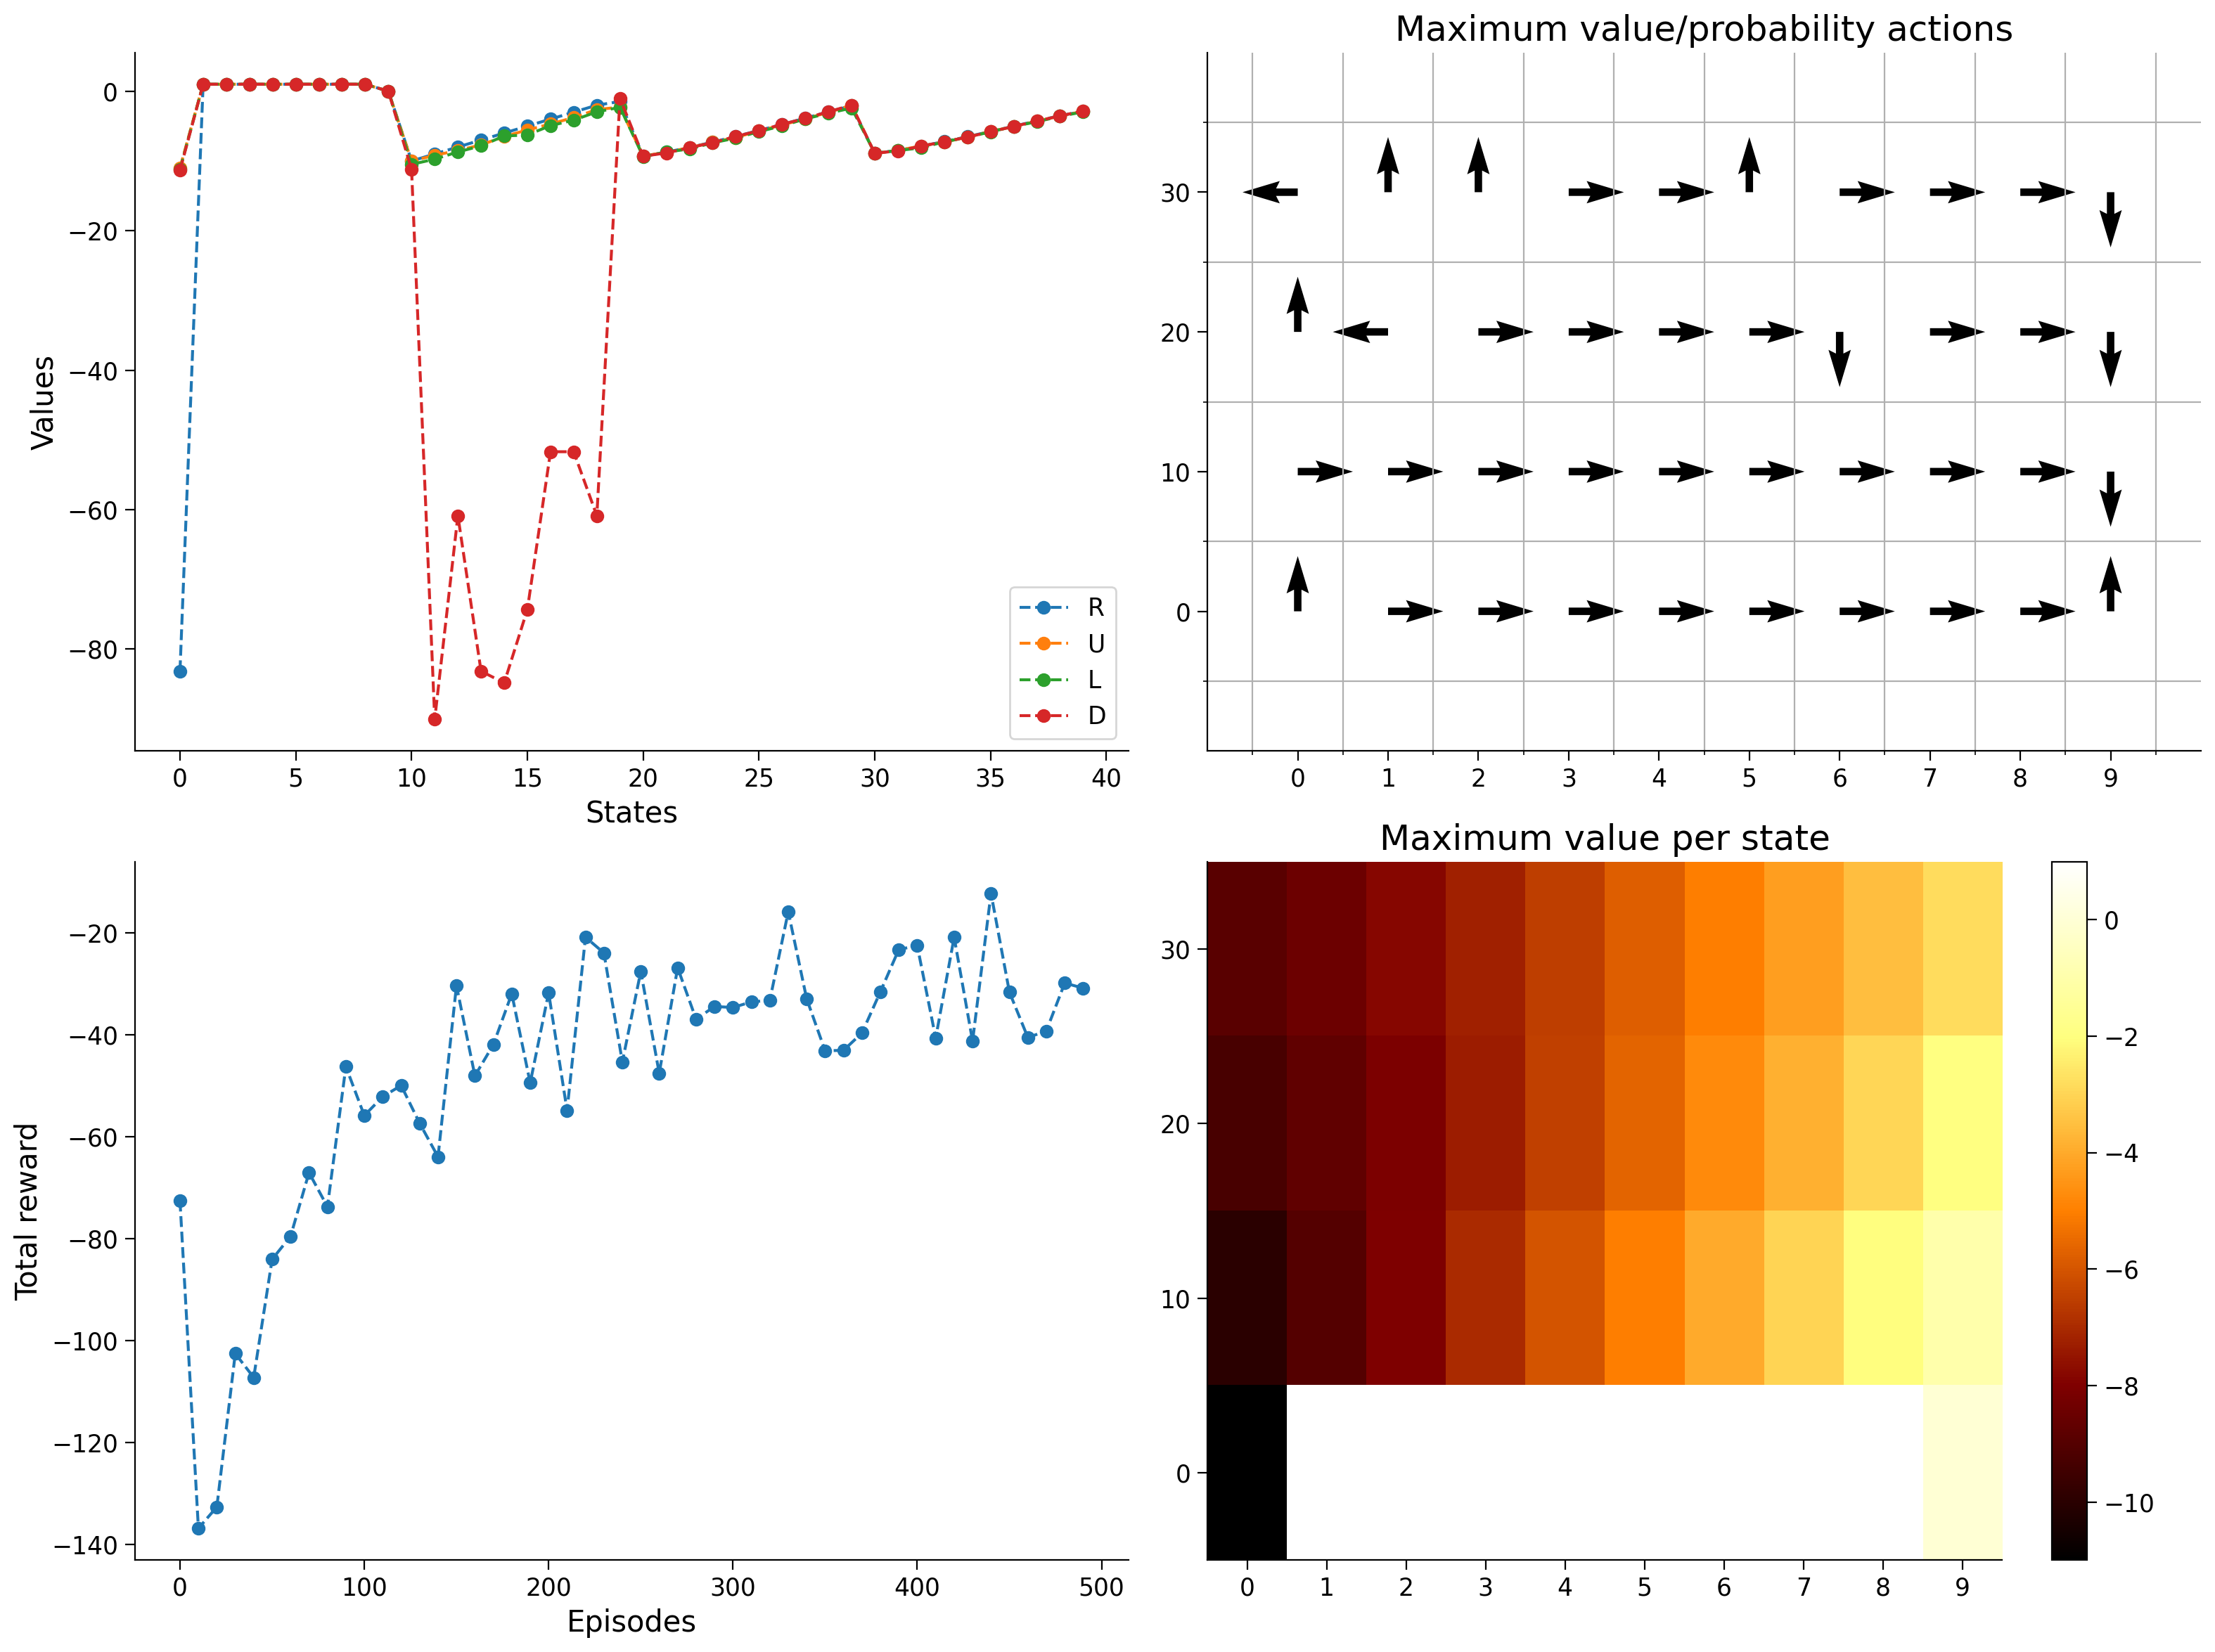

In [4]:

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise")
#############################################################################

def q_learning(state, action, reward, next_state, value, params):
  """Q-learning: updates the value function and returns it.

  Args:
    state (int): the current state identifier
    action (int): the action taken
    reward (float): the reward received
    next_state (int): the transitioned to state identifier
    value (ndarray): current value function of shape (n_states, n_actions)
    params (dict): a dictionary containing the default parameters

  Returns:
    ndarray: the updated value function of shape (n_states, n_actions)
  """
  # Q-value of current state-action pair
  q = value[state, action]

  # write an expression for finding the maximum Q-value at the current state
  if next_state is None:
    max_next_q = 0
  else:
    max_next_q = np.max(value[next_state])

  # write the expression to compute the TD error
  # hint: for the parameter dictionary,  𝛼 : params['alpha'] and  𝛾 : params['gamma']
  td_error = reward + params['gamma'] * max_next_q - q
  # write the expression that updates the Q-value for the state-action pair
  # hint: For the parameter dictionary,  𝛼 : params['alpha'] and  𝛾 : params['gamma']
  value[state, action] = value[state, action] + params['alpha'] * td_error

  return value


# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

# parameters needed by our policy and learning rule
params = {
  'epsilon': 0.1,  # epsilon-greedy policy
  'alpha': 0.1,  # learning rate
  'gamma': 1.0,  # discount factor
}

# episodes/trials
n_episodes = 500
max_steps = 1000

# environment initialization
env = CliffWorld()

# solve Cliff World using Q-learning
results = learn_environment(env, q_learning, params, max_steps, n_episodes)
value_qlearning, reward_sums_qlearning = results

# Plot results
plot_performance(env, value_qlearning, reward_sums_qlearning)


If all went well, we should see four plots that show different aspects of our agent's learning and progress.

* The top left is a representation of the Q-table itself, showing the values for different actions ('Right', 'Up', 'Left', 'Down') in different states. Notably, going right from the starting state or down when above the cliff is clearly very bad.
* The top right figure shows the greedy policy based on the Q-table, i.e. what action would the agent take if it only took its best guess in that state.
* The bottom left is the actual proof of learning, as we see the total reward steadily increasing after each episode until asymptoting at the maximum possible reward of -11.
* The bottom right is the same as the top, only instead of showing the action, it's showing a representation of the maximum Q-value at a particular state.

Feel free to try changing the parameters or random seed and see how the agent's behavior changes.

# Model-based learning

The algorithm introduced in the previous section is a one of the *model-free* algorithms, as they do not require a model to use or control behavior.

In the following section, we will study a different class of algorithms called model-based models. As we will see next, in contrast to model-free RL, model-based methods use a model to build a policy.

But what is a model? A model (sometimes called a world model or internal model) is a representation of how the world will respond to the agent's actions.

You can think of it as a representation of how the world *works*. With such a representation, the agent can simulate new experiences and learn from these simulations.

This is advantageous for two reasons.

- First, acting in the real world can be costly and sometimes even dangerous. Learning from simulated experience can avoid some of these costs or risks.

- Second, simulations make fuller use of one's limited experience.

To see why, imagine an agent interacting with the real world. The information acquired with each individual action can only be assimilated at the moment of the interaction.
  
In contrast, the experiences simulated from a model can be simulated multiple times -- and whenever desired -- allowing for the information to be more fully assimilated.

## The Bellman equations

1. **Bellman Consistency Equation** (also known as the Bellman Expectation Equation) relates the value of a state $V_\pi(s)$ under a particular policy $\pi(a|s)$ to the expected immediate reward $R(s,a)$ plus the discounted value of the next state $V_\pi(s')$ when following that same policy.

$$
V_\pi(s) = \sum_{a} \pi(a | s) \sum_{s'} P(s' | s, a) \left[ R(s, a) + \gamma V_\pi(s') \right].
$$

2. **Bellman Optimality Equation** characterizes the optimal value function $V^*(s)$, which represents the maximum expected return achievable from state $s$ by following any policy.

   It reflects the *principle of optimality*: whatever the initial decision, the remaining decisions must themselves be optimal.

$$
V^*(s) = \max_{a \in A} \sum_{s'} P(s' | s, a) \left[ R(s, a) + \gamma V^*(s') \right].
$$




These equations form the backbone of many **model based** reinforcement learning algorithms, providing a recursive framework to compute the value of states and actions.


# Dyna-Q: model-based learning with planning  

In [ ]:
# @title Set Up Code

# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve as conv

# Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")


# Plotting Functions

def plot_state_action_values(env, value, ax=None):
  """
  Generate plot showing value of each action at each state.
  """
  if ax is None:
    fig, ax = plt.subplots()

  for a in range(env.n_actions):
    ax.plot(range(env.n_states), value[:, a], marker='o', linestyle='--')
  ax.set(xlabel='States', ylabel='Values')
  ax.legend(['R','U','L','D'], loc='lower right')


def plot_quiver_max_action(env, value, ax=None):
  """
  Generate plot showing action of maximum value or maximum probability at
    each state (not for n-armed bandit or cheese_world).
  """
  if ax is None:
    fig, ax = plt.subplots()

  X = np.tile(np.arange(env.dim_x), [env.dim_y,1]) + 0.5
  Y = np.tile(np.arange(env.dim_y)[::-1][:,np.newaxis], [1,env.dim_x]) + 0.5
  which_max = np.reshape(value.argmax(axis=1), (env.dim_y,env.dim_x))
  which_max = which_max[::-1,:]
  U = np.zeros(X.shape)
  V = np.zeros(X.shape)
  U[which_max == 0] = 1
  V[which_max == 1] = 1
  U[which_max == 2] = -1
  V[which_max == 3] = -1

  ax.quiver(X, Y, U, V)
  ax.set(
      title='Maximum value/probability actions',
      xlim=[-0.5, env.dim_x+0.5],
      ylim=[-0.5, env.dim_y+0.5],
  )
  ax.set_xticks(np.linspace(0.5, env.dim_x-0.5, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_xticks(np.arange(env.dim_x+1), minor=True)
  ax.set_yticks(np.linspace(0.5, env.dim_y-0.5, num=env.dim_y))
  ax.set_yticklabels(["%d" % y for y in np.arange(0, env.dim_y*env.dim_x, env.dim_x)])
  ax.set_yticks(np.arange(env.dim_y+1), minor=True)
  ax.grid(which='minor',linestyle='-')


def plot_heatmap_max_val(env, value, ax=None):
  """
  Generate heatmap showing maximum value at each state
  """
  if ax is None:
    fig, ax = plt.subplots()

  if value.ndim == 1:
      value_max = np.reshape(value, (env.dim_y,env.dim_x))
  else:
      value_max = np.reshape(value.max(axis=1), (env.dim_y,env.dim_x))
  value_max = value_max[::-1,:]

  im = ax.imshow(value_max, aspect='auto', interpolation='none', cmap='afmhot')
  ax.set(title='Maximum value per state')
  ax.set_xticks(np.linspace(0, env.dim_x-1, num=env.dim_x))
  ax.set_xticklabels(["%d" % x for x in np.arange(env.dim_x)])
  ax.set_yticks(np.linspace(0, env.dim_y-1, num=env.dim_y))
  if env.name != 'windy_cliff_grid':
      ax.set_yticklabels(
          ["%d" % y for y in np.arange(
              0, env.dim_y*env.dim_x, env.dim_x)][::-1])
  return im


def plot_rewards(n_episodes, rewards, average_range=10, ax=None):
  """
  Generate plot showing total reward accumulated in each episode.
  """
  if ax is None:
    fig, ax = plt.subplots()

  smoothed_rewards = (conv(rewards, np.ones(average_range), mode='same')
                      / average_range)

  ax.plot(range(0, n_episodes, average_range),
          smoothed_rewards[0:n_episodes:average_range],
          marker='o', linestyle='--')
  ax.set(xlabel='Episodes', ylabel='Total reward')


def plot_performance(env, value, reward_sums):
  fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
  plot_state_action_values(env, value, ax=axes[0,0])
  plot_quiver_max_action(env, value, ax=axes[0,1])
  plot_rewards(n_episodes, reward_sums, ax=axes[1,0])
  im = plot_heatmap_max_val(env, value, ax=axes[1,1])
  fig.colorbar(im)




def plot_performance_sr(env, value, reward_sums):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
  plot_rewards(n_episodes, reward_sums, ax=axes[0])
  im = plot_heatmap_max_val(env, value, ax=axes[1])
  fig.colorbar(im)



# Helper Functions
def epsilon_greedy(q, epsilon):
  """Epsilon-greedy policy: selects the maximum value action with probabilty
  (1-epsilon) and selects randomly with epsilon probability.

  Args:
    q (ndarray): an array of action values
    epsilon (float): probability of selecting an action randomly

  Returns:
    int: the chosen action
  """
  be_greedy = np.random.random() > epsilon
  if be_greedy:
    action = np.argmax(q)
  else:
    action = np.random.choice(len(q))

  return action


def q_learning(state, action, reward, next_state, value, params):
  """Q-learning: updates the value function and returns it.

  Args:
    state (int): the current state identifier
    action (int): the action taken
    reward (float): the reward received
    next_state (int): the transitioned to state identifier
    value (ndarray): current value function of shape (n_states, n_actions)
    params (dict): a dictionary containing the default parameters

  Returns:
    ndarray: the updated value function of shape (n_states, n_actions)
  """
  # value of previous state-action pair
  prev_value = value[int(state), int(action)]

  # maximum Q-value at current state
  if next_state is None or np.isnan(next_state):
      max_value = 0
  else:
      max_value = np.max(value[int(next_state)])

  # reward prediction error
  delta = reward + params['gamma'] * max_value - prev_value

  # update value of previous state-action pair
  value[int(state), int(action)] = prev_value + params['alpha'] * delta

  return value


def learn_environment(env, model_updater, planner, params, max_steps,
                      n_episodes, shortcut_episode=None):
  # Start with a uniform value function
  value = np.ones((env.n_states, env.n_actions))

  # Run learning
  reward_sums = np.zeros(n_episodes)
  episode_steps = np.zeros(n_episodes)

  # Dyna-Q state
  model = np.nan*np.zeros((env.n_states, env.n_actions, 2))

  # Loop over episodes
  for episode in range(n_episodes):
    if shortcut_episode is not None and episode == shortcut_episode:
      env.toggle_shortcut()
      state = 64
      action = 1
      next_state, reward = env.get_outcome(state, action)
      model[state, action] = reward, next_state
      value = q_learning(state, action, reward, next_state, value, params)


    state = env.init_state  # initialize state
    reward_sum = 0

    for t in range(max_steps):
      # choose next action
      action = epsilon_greedy(value[state], params['epsilon'])

      # observe outcome of action on environment
      next_state, reward = env.get_outcome(state, action)

      # sum rewards obtained
      reward_sum += reward

      # update value function
      value = q_learning(state, action, reward, next_state, value, params)

      # update model
      model = model_updater(model, state, action, reward, next_state)

      # execute planner
      value = planner(model, value, params)

      if next_state is None:
        break  # episode ends
      state = next_state

    reward_sums[episode] = reward_sum
    episode_steps[episode] = t+1

  return value, reward_sums, episode_steps


class world(object):
    def __init__(self):
        return

    def get_outcome(self):
        print("Abstract method, not implemented")
        return

    def get_all_outcomes(self):
        outcomes = {}
        for state in range(self.n_states):
            for action in range(self.n_actions):
                next_state, reward = self.get_outcome(state, action)
                outcomes[state, action] = [(1, next_state, reward)]
        return outcomes

class QuentinsWorld(world):
    """
    World: Quentin's world.
    100 states (10-by-10 grid world).
    The mapping from state to the grid is as follows:
    90 ...       99
    ...
    40 ...       49
    30 ...       39
    20 21 22 ... 29
    10 11 12 ... 19
    0  1  2  ...  9
    54 is the start state.
    Actions 0, 1, 2, 3 correspond to right, up, left, down.
    Moving anywhere from state 99 (goal state) will end the session.
    Landing in red states incurs a reward of -1.
    Landing in the goal state (99) gets a reward of 1.
    Going towards the border when already at the border will stay in the same
        place.
    """
    def __init__(self):
        self.name = "QuentinsWorld"
        self.n_states = 100
        self.n_actions = 4
        self.dim_x = 10
        self.dim_y = 10
        self.init_state = 54
        self.shortcut_state = 64

    def toggle_shortcut(self):
      if self.shortcut_state == 64:
        self.shortcut_state = 2
      else:
        self.shortcut_state = 64

    def get_outcome(self, state, action):
        if state == 99:  # goal state
            reward = 0
            next_state = None
            return next_state, reward
        reward = 0  # default reward value
        if action == 0:  # move right
            next_state = state + 1
            if state == 98:  # next state is goal state
                reward = 1
            elif state % 10 == 9:  # right border
                next_state = state
            elif state in [11, 21, 31, 41, 51, 61, 71,
                           12, 72,
                           73,
                           14, 74,
                           15, 25, 35, 45, 55, 65, 75]:  # next state is red
                reward = -1
        elif action == 1:  # move up
            next_state = state + 10
            if state == 89:  # next state is goal state
                reward = 1
            if state >= 90:  # top border
                next_state = state
            elif state in [2, 12, 22, 32, 42, 52, 62,
                           3, 63,
                           self.shortcut_state,
                           5, 65,
                           6, 16, 26, 36, 46, 56, 66]:  # next state is red
                reward = -1
        elif action == 2:  # move left
            next_state = state - 1
            if state % 10 == 0:  # left border
                next_state = state
            elif state in [17, 27, 37, 47, 57, 67, 77,
                           16, 76,
                           75,
                           14, 74,
                           13, 23, 33, 43, 53, 63, 73]:  # next state is red
                reward = -1
        elif action == 3:  # move down
            next_state = state - 10
            if state <= 9:  # bottom border
                next_state = state
            elif state in [22, 32, 42, 52, 62, 72, 82,
                           23, 83,
                           84,
                           25, 85,
                           26, 36, 46, 56, 66, 76, 86]:  # next state is red
                reward = -1
        else:
            print("Action must be between 0 and 3.")
            next_state = None
            reward = None
        return int(next_state) if next_state is not None else None, reward








def onehot(value, max_value):
    vec = np.zeros(max_value)
    vec[value] = 1
    return vec

def twohot(value, max_value):
    vec_1 = np.zeros(max_value)
    vec_2 = np.zeros(max_value)
    vec_1[value[0]] = 1
    vec_2[value[1]] = 1
    return np.concatenate([vec_1, vec_2])

def mask_grid(grid, blocks, mask_value=-100):
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if [i,j] in blocks:
                grid[i,j] = mask_value
    grid = np.ma.masked_where(grid == mask_value, grid)
    return grid





class SimpleGrid(object):
    def __init__(self, size, block_pattern="empty",
                 verbose=False, obs_mode="onehot"):
        self.verbose = verbose
        self.grid_size = size
        self.action_size = 4
        self.obs_mode = obs_mode
        self.state_size = size*size
        self.blocks = self.make_blocks(block_pattern)
        self.goal_pos = []
        self.agent_pos = []
        self.obs_size = None
        self.done = None
        self.observations = None
        if obs_mode == "onehot":
            self.obs_size = self.state_size
            self.goal_size = self.state_size
        if obs_mode == "twohot":
            self.obs_size = self.grid_size * 2
            self.goal_size = self.grid_size * 2
        if obs_mode == "geometric":
            self.obs_size = 2
            self.goal_size = 2
        if obs_mode == "index":
            self.obs_size = 1
            self.goal_size = 1

    def reset(self, goal_pos=None, agent_pos=None):
        self.done = False
        if goal_pos != None:
            self.goal_pos = goal_pos
        else:
            self.goal_pos = self.get_free_spot()
        if agent_pos != None:
            self.agent_pos = agent_pos
        else:
            self.agent_pos = self.get_free_spot()

    def get_free_spot(self):
        free = False
        possible_x = np.arange(0, self.grid_size)
        possible_y = np.arange(0, self.grid_size)
        while not free:
            try_x = np.random.choice(possible_x, replace=False)
            try_y = np.random.choice(possible_y, replace=False)
            try_position = [try_x, try_y]
            if try_position not in self.all_positions:
                return try_position

    def make_blocks(self, pattern):
        if pattern == "four_rooms":
            mid = int(self.grid_size // 2)
            earl_mid = int(mid // 2)
            late_mid = mid+earl_mid + 1
            blocks_a = [[mid,i] for i in range(self.grid_size)]
            blocks_b = [[i,mid] for i in range(self.grid_size)]
            blocks = blocks_a + blocks_b
            self.bottlenecks = [[mid,earl_mid],[mid,late_mid],[earl_mid,mid],[late_mid,mid]]
            for bottleneck in self.bottlenecks:
                blocks.remove(bottleneck)
            return blocks
        if pattern == "empty":
            self.bottlenecks = []
            return []
        if pattern == "random":
            blocks = []
            for i in range(self.state_size // 10):
                blocks.append([np.random.randint(0, self.grid_size), np.random.randint(0, self.grid_size)])
            self.bottlenecks = []
            return blocks
        if pattern == "two_rooms":
            mid = int(self.grid_size // 2)
            blocks = [[mid,i] for i in range(self.grid_size)]
            blocks.remove([mid,mid])
            self.bottlenecks = [[mid,mid]]
            return blocks

    @property
    def grid(self):
        grid = np.zeros([self.grid_size, self.grid_size, 3])
        grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        grid[self.goal_pos[0], self.goal_pos[1], 1] = 1
        for block in self.blocks:
            grid[block[0], block[1], 2] = 1
        return grid

    def move_agent(self, direction):
        new_pos = self.agent_pos + direction
        if self.check_target(new_pos):
            self.agent_pos = list(new_pos)

    def simulate(self, action):
        agent_old_pos = self.agent_pos
        reward = self.step(action)
        state = self.state
        self.agent_pos = agent_old_pos
        return state

    def check_target(self, target):
        x_check = target[0] > -1 and target[0] < self.grid_size
        y_check = target[1] > -1 and target[1] < self.grid_size
        block_check = list(target) not in self.blocks
        if x_check and y_check and block_check:
            return True
        else:
            return False

    @property
    def observation(self):
        if self.obs_mode == "onehot":
            return onehot(self.agent_pos[0] * self.grid_size + self.agent_pos[1], self.state_size)
        if self.obs_mode == "twohot":
            return self.twohot(self.agent_pos, self.grid_size)
        if self.obs_mode == "geometric":
            return (2 * np.array(self.agent_pos) / (self.grid_size-1)) - 1
        if self.obs_mode == "visual":
            return env.grid
        if self.obs_mode == "index":
            return self.agent_pos[0] * self.grid_size + self.agent_pos[1]

    @property
    def goal(self):
        if self.obs_mode == "onehot":
            return onehot(self.goal_pos[0] * self.grid_size + self.goal_pos[1], self.state_size)
        if self.obs_mode == "twohot":
            return self.twohot(self.goal_pos, self.grid_size)
        if self.obs_mode == "geometric":
            return (2 * np.array(self.goal_pos) / (self.grid_size-1)) - 1
        if self.obs_mode == "visual":
            return env.grid
        if self.obs_mode == "index":
            return self.goal_pos[0] * self.grid_size + self.goal_pos[1]

    @property
    def all_positions(self):
        all_positions = self.blocks + [self.goal_pos] + [self.agent_pos]
        return all_positions

    def state_to_grid(self, state):
        vec_state = np.zeros([self.state_size])
        vec_state[state] = 1
        vec_state = np.reshape(vec_state, [self.grid_size, self.grid_size])
        return vec_state

    def state_to_goal(self, state):
        return onehot(state, self.state_size)

    def state_to_point(self, state):
        a = self.state_to_grid(state)
        b = np.where(a==1)
        c = [b[0][0],b[1][0]]
        return c

    def state_to_obs(self, state):
        if self.obs_mode == "onehot":
            point = self.state_to_point(state)
            return onehot(point[0] * self.grid_size + point[1], self.state_size)
        if self.obs_mode == "twohot":
            point = self.state_to_point(state)
            return self.twohot(point, self.grid_size)
        if self.obs_mode == "geometric":
            point = self.state_to_point(state)
            return (2 * np.array(point) / (self.grid_size-1)) - 1
        if self.obs_mode == "visual":
            return self.state_to_grid(state)
        if self.obs_mode == "index":
            return state

    def step(self, action):
        # 0 - Up
        # 1 - Down
        # 2 - Left
        # 3 - Right
        move_array = np.array([0,0])
        if action == 2:
            move_array = np.array([0,-1])
        if action == 3:
            move_array = np.array([0,1])
        if action == 0:
            move_array = np.array([-1,0])
        if action == 1:
            move_array = np.array([1,0])
        self.move_agent(move_array)
        if self.agent_pos == self.goal_pos:
            self.done = True
            return 1.0
        else:
            return 0.0

    def state_to_goal(self, state):
        return self.state_to_obs(state)

##**Quentin's World Environment**

In this section, our RL agent will act in the Quentin's world, a 10x10 grid world.

<img alt="QuentinsWorld" width="560" height="560" src="https://github.com/NeuromatchAcademy/course-content/blob/main/tutorials/static/W3D4_Tutorial4_QuentinsWorld.png?raw=true">

In this environment, there are 100 states and 4 possible actions: right, up, left, and down. The goal of the agent is to move, via a series of steps, from the start (green) location to the goal (yellow) region, while avoiding the red walls. More specifically:

* The agent starts in the green state,
* Moving into one of the red states incurs a reward of -1,
* Moving into the world borders stays in the same place,
* Moving into the goal state (yellow square in the upper right corner) gives you a reward of 1, and
* Moving anywhere from the goal state ends the episode.

Now that we have our environment and task defined, how can we solve this using a model-based RL agent?

## Concepts

We may solve the above problem using a model-based algorithm: Dyna-Q, one of the simplest model-based reinforcement learning algorithms.

A Dyna-Q agent combines learning, acting, and planning. The first two components -- learning and acting -- are just like what we have studied previously. Q-learning, for example, learns by acting in the world, and therefore combines learning and acting. But a Dyna-Q agent also implements planning, or simulating experiences from a model--and learns from them.

In theory, one can think of a Dyna-Q agent as implementing learning, acting, and planning simultaneously, at all times. But, in practice, one needs to specify the algorithm as a sequence of steps. The most common way in which the Dyna-Q agent is implemented is by adding a planning routine to a Q-learning agent: after the agent acts in the real world and learns from the observed experience, the agent is allowed a series of $k$ *planning steps*. At each one of those $k$ planning steps, the model generates a simulated experience by randomly sampling from the history of all previously experienced state-action pairs. The agent then learns from this simulated experience, again using the same Q-learning rule that implemented for learning from real experience. This simulated experience is simply a one-step transition, i.e., a state, an action, and the resulting state and reward. So, in practice, a Dyna-Q agent learns (via Q-learning) from one step of **real** experience during acting, and then from k steps of **simulated** experience during planning.

There's one final detail about this algorithm: where does the simulated experiences come from or, in other words, what is the "model"? In Dyna-Q, as the agent interacts with the environment, the agent also learns the model. For simplicity, Dyna-Q implements model-learning in an almost trivial way, as simply caching the results of each transition. Thus, after each one-step transition in the environment, the agent saves the results of this transition in a big matrix, and consults that matrix during each of the planning steps. Obviously, this model-learning strategy only makes sense if the world is deterministic (so that each state-action pair always leads to the same state and reward), and this is the setting of the exercise below. However, even this simple setting can already highlight one of Dyna-Q major strengths: the fact that the planning is done at the same time as the agent interacts with the environment, which means that new information gained from the interaction may change the model and thereby interact with planning in potentially interesting ways.

Since we already implemented Q-learning, we will focus here on the extensions new to Dyna-Q: the model update step and the planning step.

For reference, here's the Dyna-Q algorithm that you will help implement:

---
**TABULAR DYNA-Q**

Initialize $Q(s,a)$ and $Model(s,a)$ for all $s \in S$ and $a \in A$.

Loop forever:

> (a) $S$ &larr; current (nonterminal) state <br>
> (b) $A$ &larr; $\epsilon$-greedy$(S,Q)$ <br>
> (c) Take action $A$; observe resultant reward, $R$, and state, $S'$ <br>
> (d) $Q(S,A)$ &larr; $Q(S,A) + \alpha \left[R + \gamma \max_{a} Q(S',a) - Q(S,A)\right]$ <br>
> (e) $Model(S,A)$ &larr; $R,S'$ (assuming deterministic environment) <br>
> (f) Loop repeat $k$ times: <br>
>> $S$ &larr; random previously observed state <br>
>> $A$ &larr; random action previously taken in $S$ <br>
>> $R,S'$ &larr; $Model(S,A)$ <br>
>> $Q(S,A)$ &larr; $Q(S,A) + \alpha \left[R + \gamma \max_{a} Q(S',a) - Q(S,A)\right]$ <br>


---

## Dyna-Q Model Update

We will implement the model update portion of the Dyna-Q algorithm. More specifically, after each action that the agent executes in the world, we need to update our model to remember what reward and next state we last experienced for a given state-action pair.

In [ ]:

def dyna_q_model_update(model, state, action, reward, next_state):
  """ Dyna-Q model update

  Args:
    model (ndarray): An array of shape (n_states, n_actions, 2) that represents
                     the model of the world i.e. what reward and next state do
                     we expect from taking an action in a state.
    state (int): the current state identifier
    action (int): the action taken
    reward (float): the reward received
    next_state (int): the transitioned to state identifier

  Returns:
    ndarray: the updated model
  """
  # Update our model with the observed reward and next state
  model[state, action] = reward, next_state

  return model

Now that we have a way to update our model, we can use it in the planning phase of Dyna-Q to simulate past experiences.

## Dyna-Q Planning

We will then implement the other key part of Dyna-Q: planning. We will sample a random state-action pair from those we've experienced, use our model to simulate the experience of taking that action in that state, and update our value function using Q-learning with these simulated state, action, reward, and next state outcomes. Furthermore, we want to run this planning step $k$ times, which can be obtained from `params['k']`.

We may use the `q_learning` function to handle the Q-learning value function update. Recall that the method signature is `q_learning(state, action, reward, next_state, value, params)` and it returns the updated `value` table.

After completing this function, we have a way to update our model and a means to use it in planning so we will see it in action. The code sets up our agent parameters and learning environment, then passes your model update and planning methods to the agent to try and solve Quentin's World. Notice that we set the number of planning steps $k=10$.

# Coding Exercise #2 and Coding Exercise #3

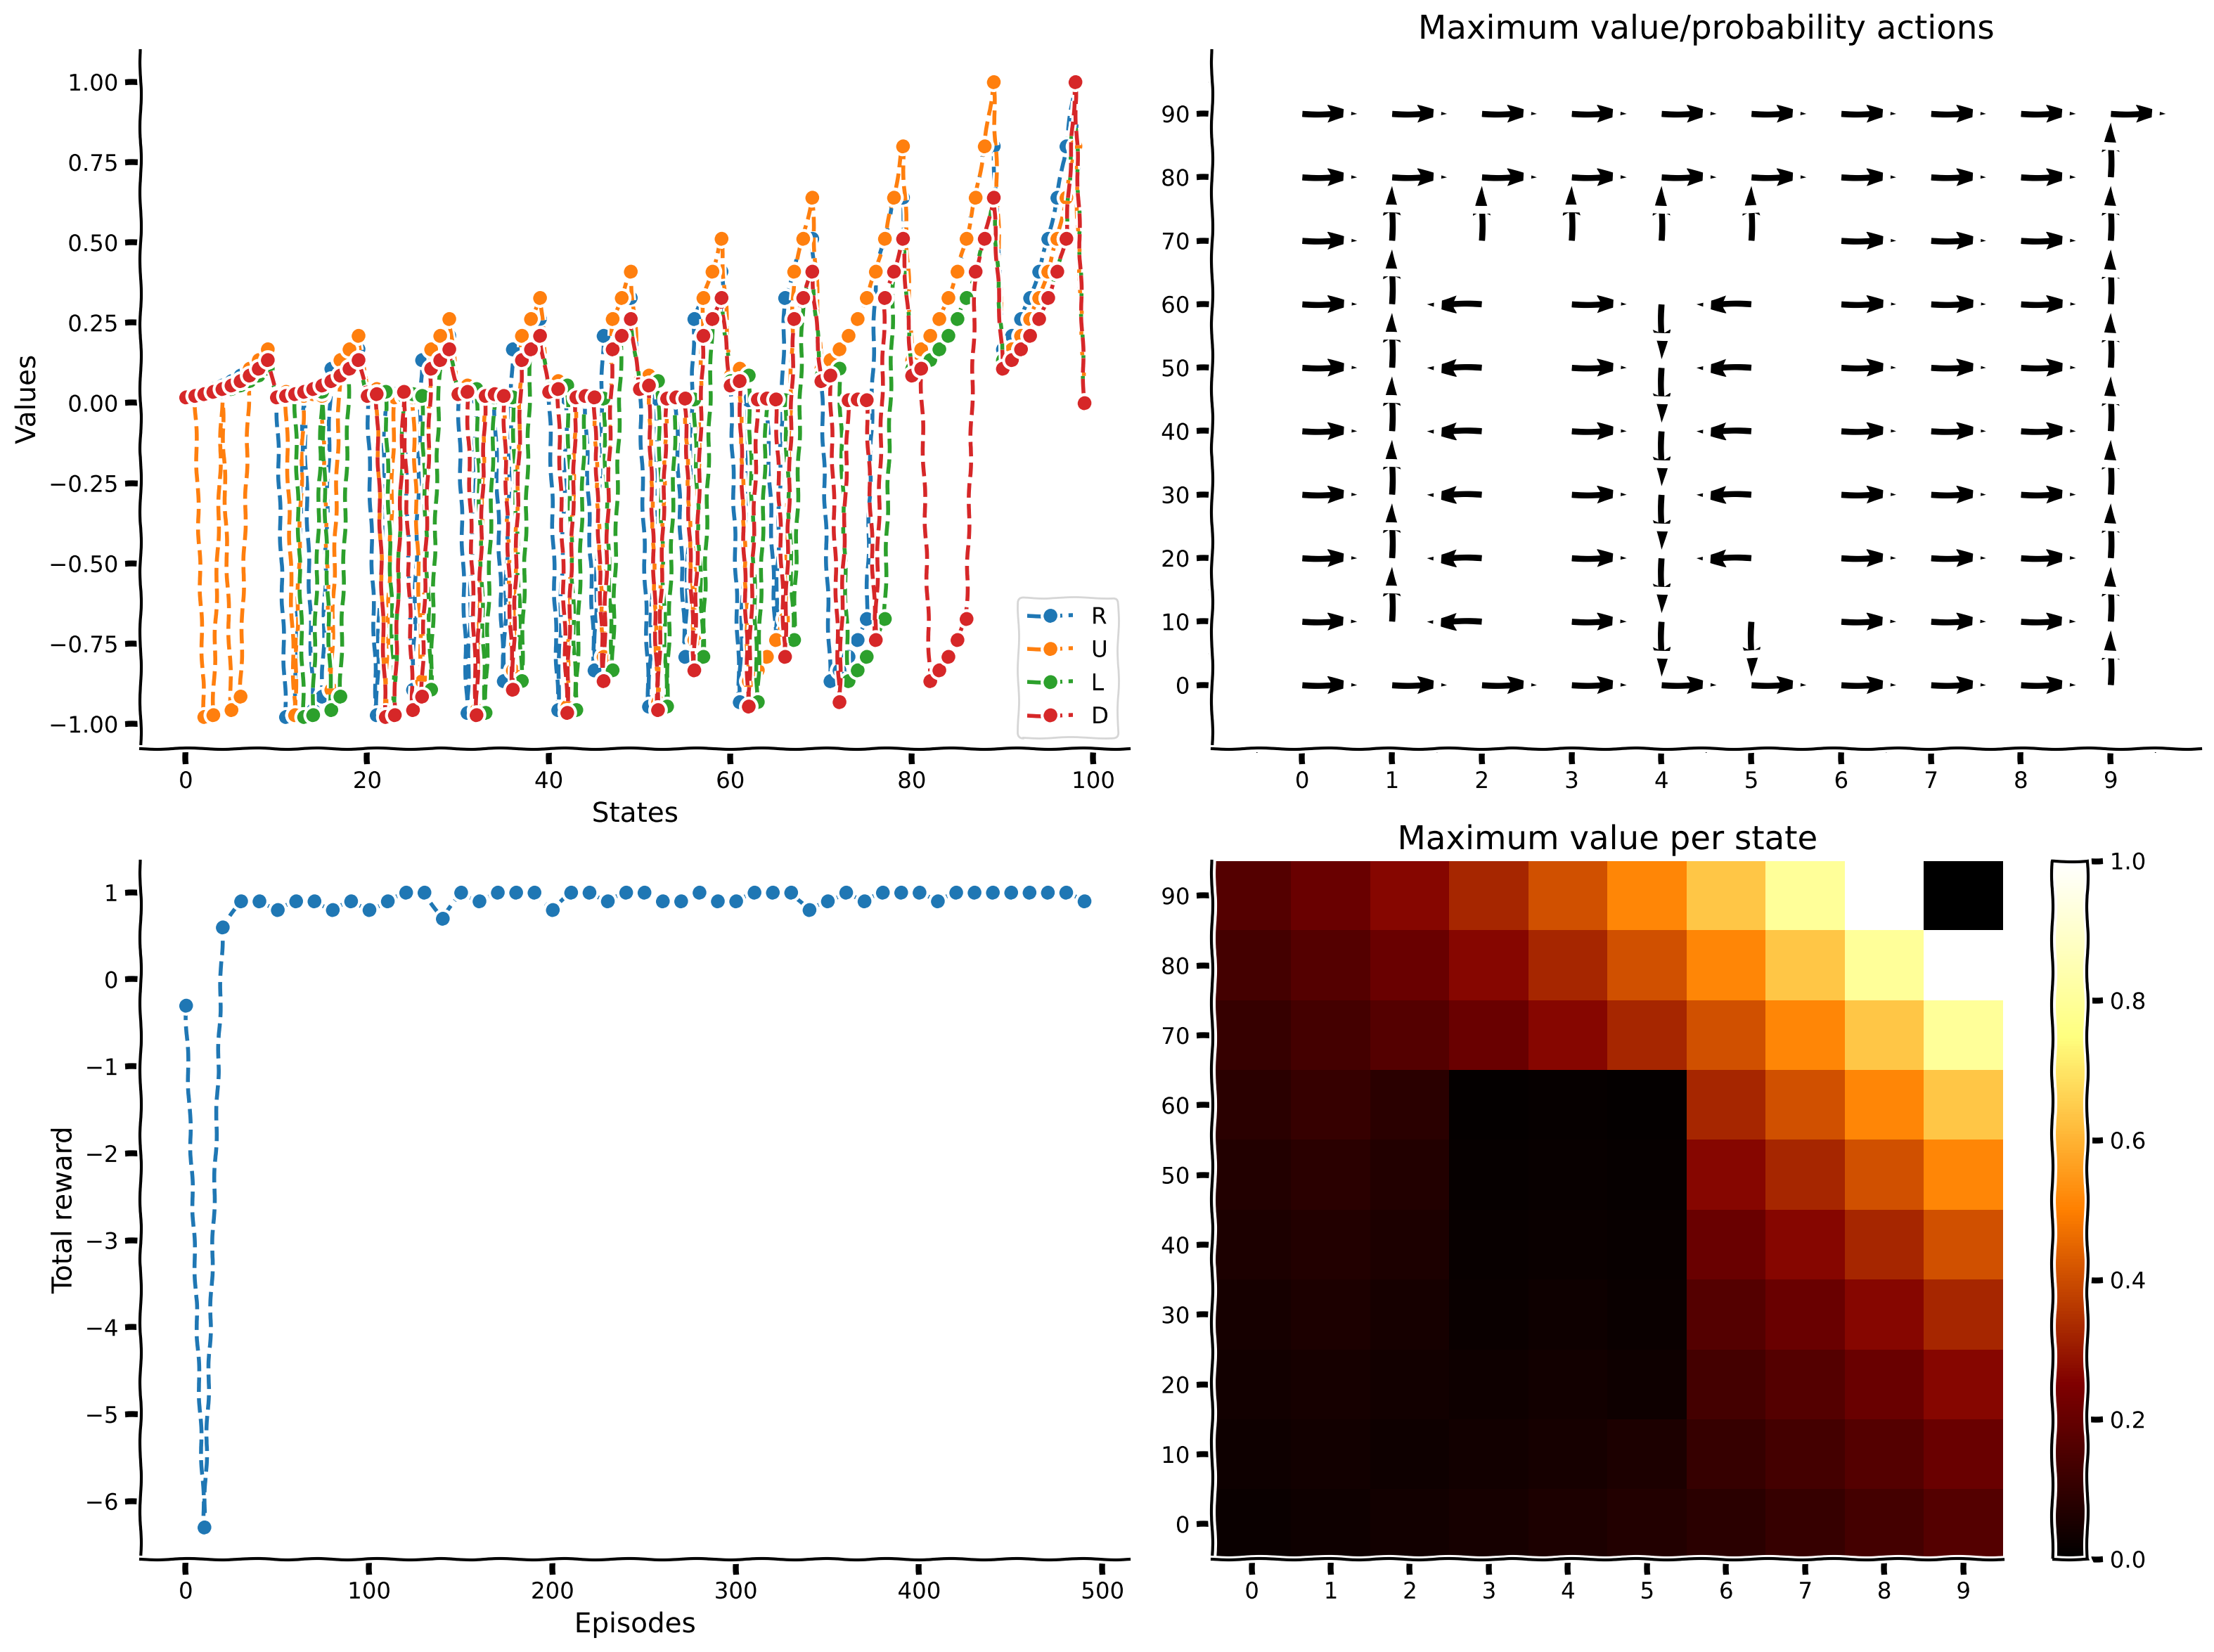

In [ ]:

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise")
#############################################################################

def dyna_q_planning(model, value, params):
  """ Dyna-Q planning

  Args:
    model (ndarray): An array of shape (n_states, n_actions, 2) that represents
                     the model of the world i.e. what reward and next state do
                     we expect from taking an action in a state.
    value (ndarray): current value function of shape (n_states, n_actions)
    params (dict): a dictionary containing learning parameters

  Returns:
    ndarray: the updated value function of shape (n_states, n_actions)
  """
  # Perform k additional updates at random (planning)
  for _ in range(params['k']):
    # Find state-action combinations for which we've experienced a reward i.e.
    # the reward value is not NaN. The outcome of this expression is an Nx2
    # matrix, where each row is a state and action value, respectively.
    candidates = np.array(np.where(~np.isnan(model[:,:,0]))).T

    # Write an expression for selecting a random row index from our candidates
    idx = np.random.choice(len(candidates))

    # Obtain the randomly selected state and action values from the candidates
    state, action = candidates[idx]

    # Obtain the expected reward and next state from the model
    reward, next_state = model[state, action]

    # Update the value function using Q-learning
    value = q_learning(state, action, reward, next_state, value, params)

  return value


#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise")
#############################################################################

def learn_environment(env, model_updater, planner, params, max_steps,
                      n_episodes, shortcut_episode=None):
  # Start with a uniform value function
  value = np.ones((env.n_states, env.n_actions))

  # Run learning
  reward_sums = np.zeros(n_episodes)
  episode_steps = np.zeros(n_episodes)

  # Dyna-Q state
  model = np.nan*np.zeros((env.n_states, env.n_actions, 2))

  # Loop over episodes
  for episode in range(n_episodes):
    if shortcut_episode is not None and episode == shortcut_episode:
      env.toggle_shortcut()
      state = 64
      action = 1
      next_state, reward = env.get_outcome(state, action)
      model[state, action] = reward, next_state
      value = q_learning(state, action, reward, next_state, value, params)


    state = env.init_state  # initialize state
    reward_sum = 0

    for t in range(max_steps):
      # choose next action
      action = epsilon_greedy(value[state], params['epsilon'])

      # observe outcome of action on environment
      next_state, reward = env.get_outcome(state, action)

      # sum rewards obtained
      reward_sum += reward

      # update value function
      value = q_learning(state, action, reward, next_state, value, params)

      # update model
      model = dyna_q_model_update(model, state, action, reward, next_state)

      # execute planner
      value = dyna_q_planning(model, value, params)

      if next_state is None:
        break  # episode ends
      state = next_state

    reward_sums[episode] = reward_sum
    episode_steps[episode] = t+1

  return value, reward_sums, episode_steps



# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

# parameters needed by our policy and learning rule
params = {
  'epsilon': 0.05,  # epsilon-greedy policy
  'alpha': 0.5,  # learning rate
  'gamma': 0.8,  # temporal discount factor
  'k': 10,  # number of Dyna-Q planning steps
}

# episodes/trials
n_episodes = 500
max_steps = 1000

# environment initialization
env = QuentinsWorld()

# solve Quentin's World using Dyna-Q
results = learn_environment(env, dyna_q_model_update, dyna_q_planning,
                            params, max_steps, n_episodes)
value, reward_sums, episode_steps = results

# Plot the results
with plt.xkcd():
  plot_performance(env, value, reward_sums)

Upon completion, we should see that our Dyna-Q agent is able to solve the task quite quickly, achieving a consistent positive reward after only a limited number of episodes (bottom left).

## How much to plan?

Now that we have implemented a Dyna-Q agent with $k=10$, we will try to understand the effect of planning on performance. How does changing the value of $k$ impact our agent's ability to learn?

The following code is similar to what we just ran, only this time we run several experiments over several different values of $k$ to see how their average performance compares. In particular, we will choose $k \in \{0, 1, 10, 100\}$. Pay special attention to the case where $k = 0$ which corresponds to no planning. This is, in effect, just regular Q-learning.

The following code will take a bit of time to complete. To speed things up, try lowering the number of experiments or the number of $k$ values to compare.

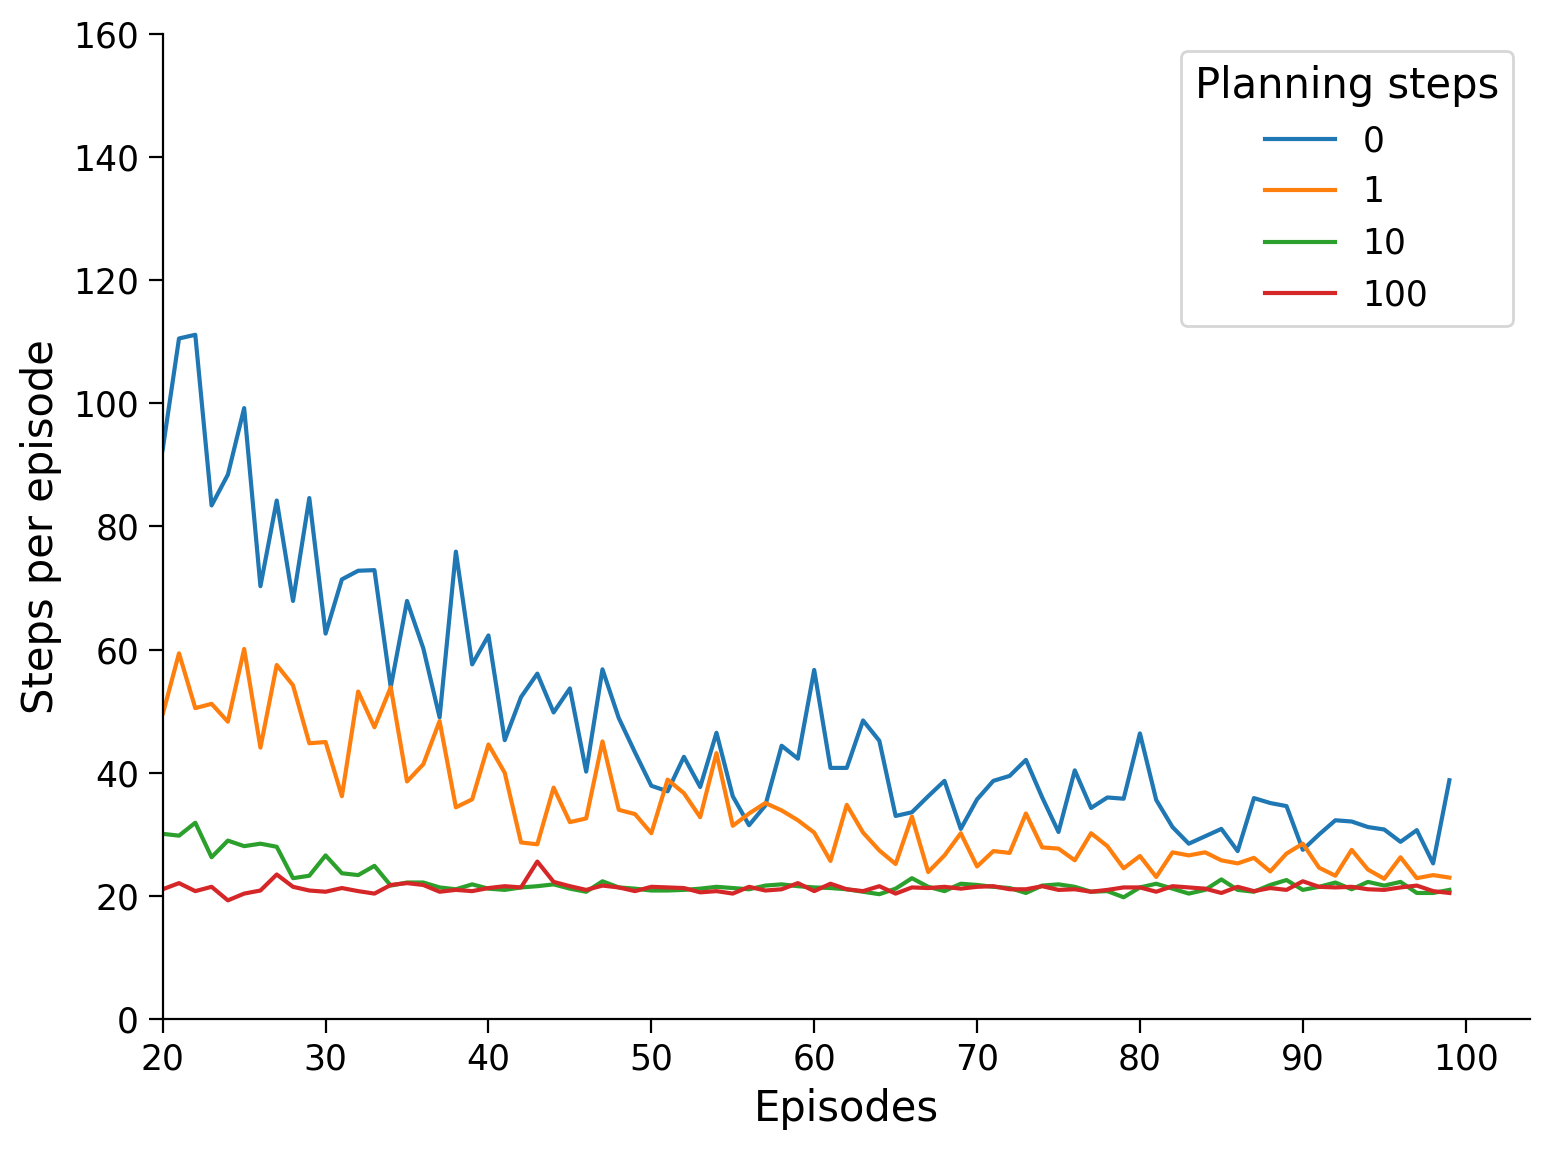

In [ ]:

# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

# parameters needed by our policy and learning rule
params = {
  'epsilon': 0.05,  # epsilon-greedy policy
  'alpha': 0.5,  # learning rate
  'gamma': 0.8,  # temporal discount factor
}

# episodes/trials
n_experiments = 10
n_episodes = 100
max_steps = 1000

# number of planning steps
planning_steps = np.array([0, 1, 10, 100])

# environment initialization
env = QuentinsWorld()

steps_per_episode = np.zeros((len(planning_steps), n_experiments, n_episodes))

for i, k in enumerate(planning_steps):
  params['k'] = k
  for experiment in range(n_experiments):
    results = learn_environment(env, dyna_q_model_update, dyna_q_planning,
                                params, max_steps, n_episodes)
    steps_per_episode[i, experiment] = results[2]

# Average across experiments
steps_per_episode = np.mean(steps_per_episode, axis=1)

# Plot results
fig, ax = plt.subplots()
ax.plot(steps_per_episode.T)
ax.set(xlabel='Episodes', ylabel='Steps per episode',
       xlim=[20, None], ylim=[0, 160])
ax.legend(planning_steps, loc='upper right', title="Planning steps");

After an initial warm-up phase of the first 20 episodes, we should see that the number of planning steps has a noticeable impact on our agent's ability to rapidly solve the environment. We should also notice that after a certain value of $k$ our relative utility goes down, so it's important to balance a large enough value of $k$ that helps us learn quickly without wasting too much time in planning.

## When the world changes...

In addition to speeding up learning about a new environment, planning can also help the agent to quickly incorporate new information about the environment into its policy. Thus, if the environment changes (e.g. the rules governing the transitions between states, or the rewards associated with each state/action), the agent doesn't need to experience that change *repeatedly* in real experience (as would be required in a Q-learning agent). Instead, planning allows that change to be incorporated quickly into the agent's policy, without the need to experience the change more than once.

In this section, we will again have our agents attempt to solve Quentin's World. However, after 200 episodes, a shortcut will appear in the environment.  We will test how a model-free agent using Q-learning and a Dyna-Q agent adapt to this change in the environment.

<img alt="QuentinsWorldShortcut" width="560" height="560" src="https://github.com/NeuromatchAcademy/course-content/blob/main/tutorials/static/W3D4_Tutorial4_QuentinsWorldShortcut.png?raw=true">

The following code again looks similar to what we've run previously. Just as above we will have multiple values for $k$, with $k=0$ representing our Q-learning agent and $k=10$ for our Dyna-Q agent with 10 planning steps. The main difference is we now add in an indicator as to when the shortcut appears. In particular, we will run the agents for 400 episodes, with the shortcut appearing in the middle after episode #200.

When this shortcut appears we will also let each agent experience this change once i.e. we will evaluate the act of moving upwards when in the state that is below the now-open shortcut. After this single demonstration, the agents will continue on interacting in the environment.

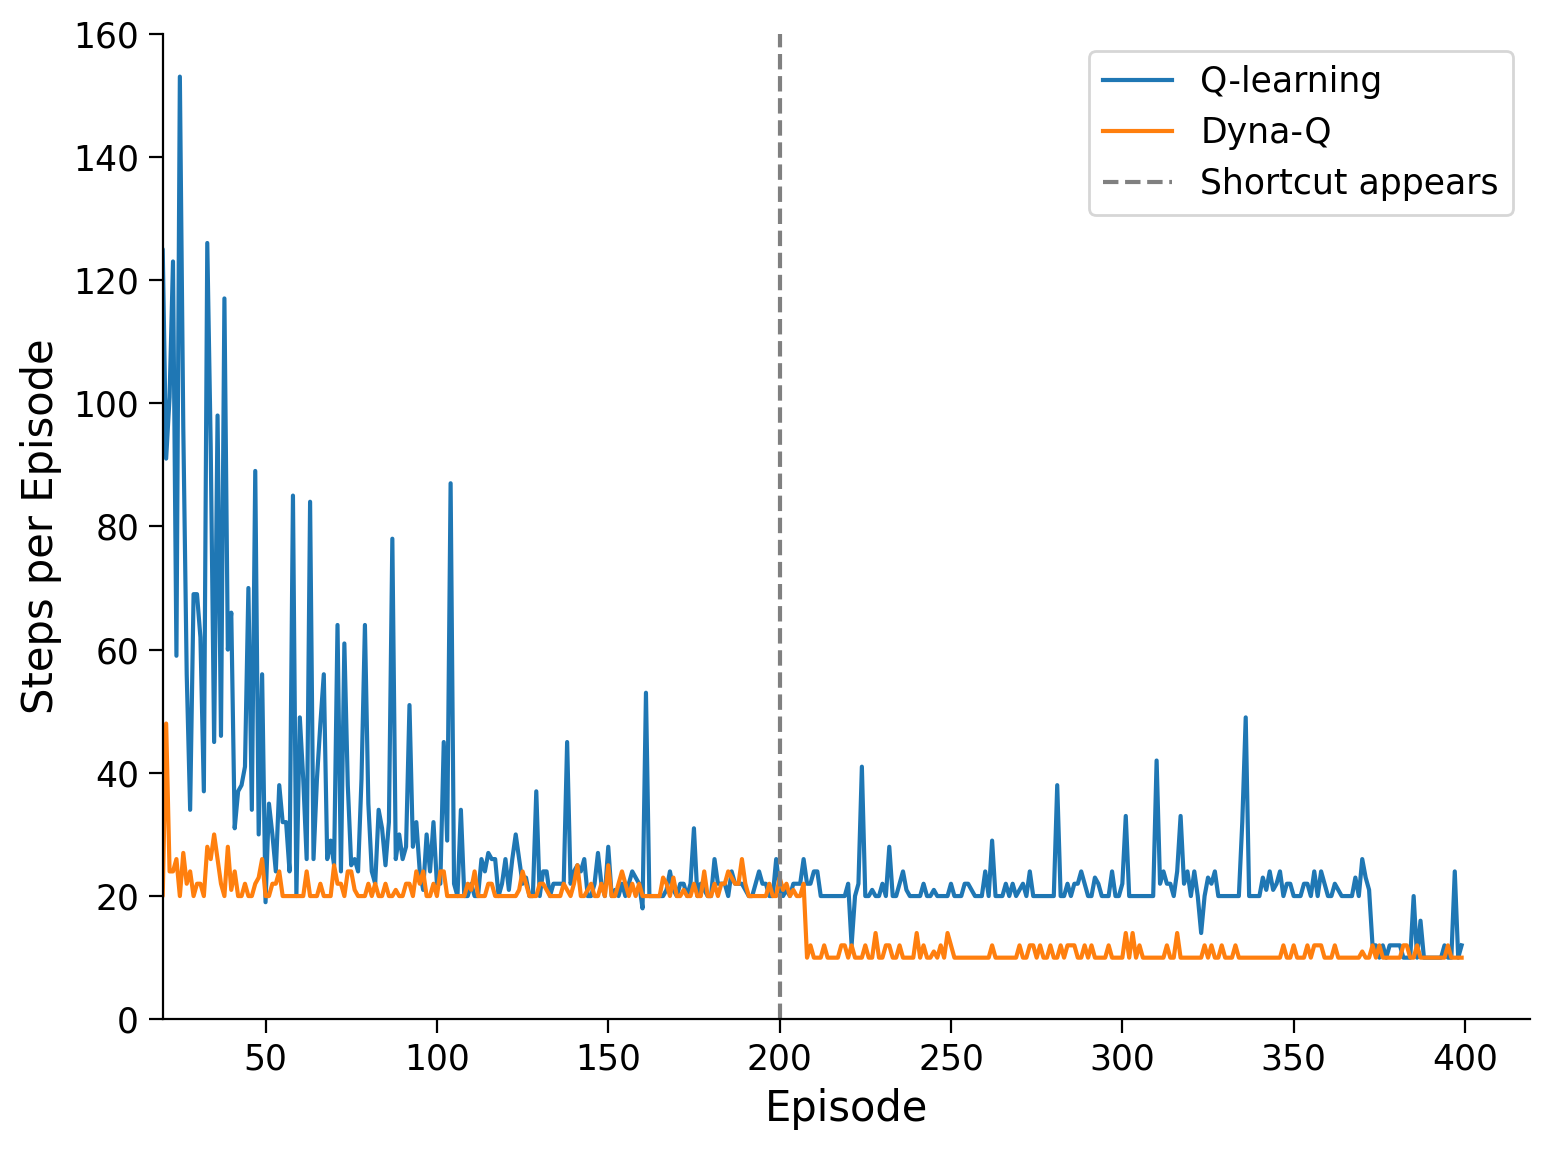

In [ ]:

# set for reproducibility, comment out / change seed value for different results
np.random.seed(1)

# parameters needed by our policy and learning rule
params = {
  'epsilon': 0.05,  # epsilon-greedy policy
  'alpha': 0.5,  # learning rate
  'gamma': 0.8,  # temporal discount factor
}

# episodes/trials
n_episodes = 400
max_steps = 1000
shortcut_episode = 200  # when we introduce the shortcut

# number of planning steps
planning_steps = np.array([0, 10]) # Q-learning, Dyna-Q (k=10)

# environment initialization
steps_per_episode = np.zeros((len(planning_steps), n_episodes))

# Solve Quentin's World using Q-learning and Dyna-Q
for i, k in enumerate(planning_steps):
  env = QuentinsWorld()
  params['k'] = k
  results = learn_environment(env, dyna_q_model_update, dyna_q_planning,
                              params, max_steps, n_episodes,
                              shortcut_episode=shortcut_episode)
  steps_per_episode[i] = results[2]


# Plot results
fig, ax = plt.subplots()
ax.plot(steps_per_episode.T)
ax.set(xlabel='Episode', ylabel='Steps per Episode',
       xlim=[20,None], ylim=[0, 160])
ax.axvline(shortcut_episode, linestyle="--", color='gray', label="Shortcut appears")
ax.legend(('Q-learning', 'Dyna-Q', 'Shortcut appears'),
          loc='upper right');

# Question 1

What do you observe in the results shown above? Which model do you think can adapt to the shortcut changes more quickly, Dyna-Q or Q learning? Why?

Dyna-Q adapts to the updated environment (shortcut changes) quickly as it is model based learning algorithm and the updates are incorporated in the model during planning at every episode.

# Successor Representation (SR) Reinforcement Learning: a model between model-free and model-based

## Concepts

Successor Representation (SR) is a technique in reinforcement learning (RL) that decomposes the value function into two components:

1. **Successor Representation ($ M^\pi $)**: It is the **discounted cumulative future state occupancy**. It captures how often each state is expected to be visited under a policy $ \pi $.
2. **Reward Function ($ R $)**: Specifies the immediate reward for each state.

By separating **state transition dynamics** from **reward structure**, SR enables faster adaptation when rewards change.


In standard RL, the **state-value function** is:

$$
V^\pi(s) = \mathbb{E} \left[ \sum_{t=0}^{\infty} \gamma^t R(s_t) \mid s_0 = s, \pi \right].
$$

Instead of directly estimating $V^\pi(s)$, SR expresses it as:

$$
V^\pi(s) = \sum_{s'} M^\pi(s, s') R(s').
$$


$$
M^\pi(s, s') = \mathbb{E} \left[ \sum_{t=0}^{\infty} \gamma^t \mathbb{1}(s_t = s') \mid s_0 = s , \pi \right]
$$


or in terms of state-action value function $Q$:

$$
Q^\pi(s,a) = \mathbb{E} \left[ \sum_{t=0}^{\infty} \gamma^t R(s_t,a_t) \mid s_0 = s, a_0 = a, \pi \right].
$$

$$
Q^\pi(s,a) = \sum_{s'} M^\pi(s, a, s') R(s').
$$

$$
M^\pi(s, a, s') = \mathbb{E} \left[ \sum_{t=0}^{\infty} \gamma^t \mathbb{1}(s_t = s') \mid s_0 = s, a_0 = a, \pi \right]
$$

where:
- $ M^\pi(s, s') $ is the **Successor Representation**, which measures the expected future occupancy of state $ s' $ given that the agent starts in $ s $ and follows policy $ \pi $.
- $ M^\pi(s, a, s') $ is also the **Successor Representation**, which measures the expected future occupancy of state $ s' $ given that the agent starts in $ s $ and takes action $a$.
- $ R(s') $ is the reward at state $ s' $.


**Relationship between State Successor Representation and Action Successor Representation**

The state value function is the expected action value under the policy:

$$
V^\pi(s)
=
\sum_a \pi(a \mid s)\, Q^\pi(s,a)
$$

Correspondingly, the state successor representation is the expected action successor representation under the policy:

$$
M^\pi(s,s')
=
\sum_a \pi(a \mid s)\, M^\pi(s,a,s')
$$

# Interpretation

- $$M^\pi(s,a,s')$$: successor representation if you start in state $$s$$ and take action $$a$$ first.
- $$M^\pi(s,s')$$: successor representation if you start in state $$s$$ and follow policy $$\pi$$.

The state successor representation is simply the policy-weighted average of the action successor representations.





**Learning the Successor Representation**

First, we initialize the successor matrix $M^\pi$ as an identity matrix (for all actions $a_t$), i.e.:

$$
M^\pi(s_t, s_{t+1}) =
\begin{cases}
1, & \text{if } s_t = s_{t+1}, \\
0, & \text{otherwise}.
\end{cases}
$$

or

$$
M^\pi(s_t, a_t, s_{t+1}) =
\begin{cases}
1, & \text{if } s_t = s_{t+1}, \\
0, & \text{otherwise}.
\end{cases}
$$

The successor matrix $ M^\pi $ is learned using a Temporal Difference (TD)-like update.

For all states $s' \in S$, we update $ M^\pi $ in the following way:

$$
M^\pi(s_t, s') \leftarrow (1 - \alpha) M^\pi(s_t, s') + \alpha \left[ \mathbb{1}\{s' = s_t\} + \gamma M^\pi(s_{t+1}, s') \right] \\= M^\pi(s_t, s') + \alpha \left[ \mathbb{1}\{s' = s_t\} + \gamma M^\pi(s_{t+1}, s') - M^\pi(s_t, s') \right].
$$

or

$$
M^\pi(s_t, a_t, s') \leftarrow (1 - \alpha) M^\pi(s_t, a_t, s') + \alpha \left[ \mathbb{1}\{s' = s_t\} + \gamma M^\pi(s_{t+1}, a_{t+1}, s') \right] \\= M^\pi(s_t, a_t, s') + \alpha \left[ \mathbb{1}\{s' = s_t\} + \gamma M^\pi(s_{t+1}, a_{t+1}, s') - M^\pi(s_t, a_t, s') \right].
$$

where:
- $s_t$ is the current state
- $s_{t+1}$ is the state at the next time step
- $s'$ is any state in the state space
- $ \mathbb{1}\{s' = s_t\} $ is an indicator function (1 if $ s' = s_t $, else 0),
- $ \gamma $ is the discount factor,
- $ \alpha $ is the learning rate.



**Advantages of Successor Representation**

**Fast Adaptation**: If the reward function changes but the transition dynamics remain the same, SR enables quick recomputation of $ V^\pi(s) $.  
**Transfer Learning**: Useful in multi-task RL where transition dynamics are shared, but goals (rewards) differ.  
**Representation Learning**: Provides a structured state representation that facilitates planning and exploration.



**Limitations**

**Storage Issues**: For large state spaces, storing $ M^\pi $ can be expensive. Function approximation (e.g., neural networks) helps scale SR to high-dimensional tasks.  
**Exploration Challenges**: As in other RL methods, balancing exploration vs. exploitation is crucial.



**Key Takeaways**

- **Successor Representation** decomposes value computation into *expected future state visitations* and *reward mapping*.
- **SR is useful for fast adaptation to reward changes and transfer learning**.
- **Recent work in deep RL generalizes SR using neural networks** (*e.g., deep successor features*).

**Successor Representation bridges neuroscience and RL, providing a biologically plausible way to model predictive learning.**


Here is a simple gridworld environment with four rooms. In this environment a specific state in the rightmost green room contains a treasure chest and provides an agent with a +1 reward, and all other states provide no reward.

The agent's position is marked in red, the walls are marked in blue, and the goal position is marked in green.


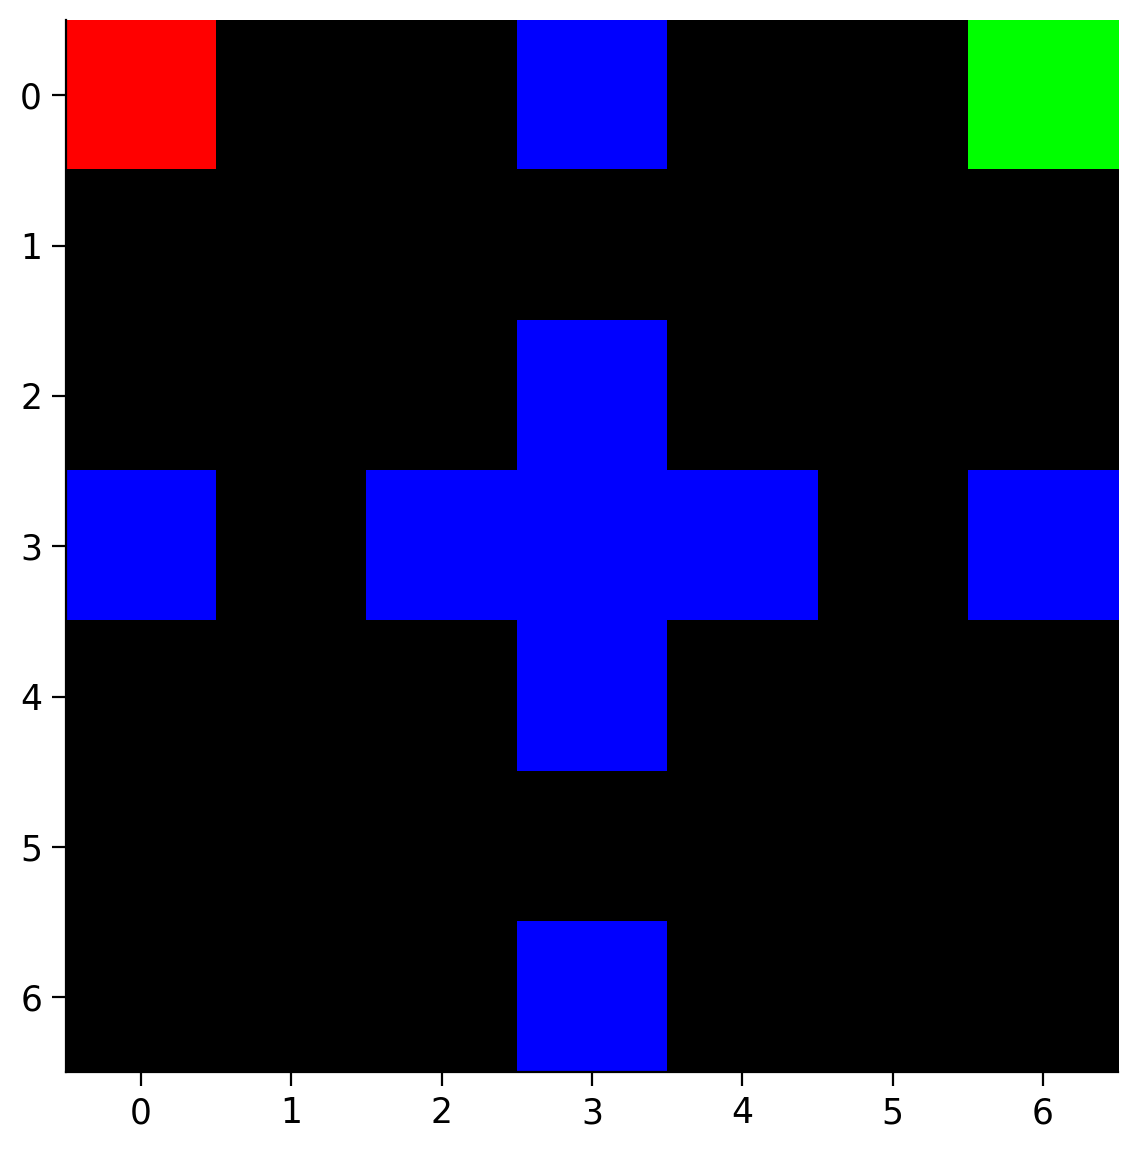

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
# import utils
from sklearn.decomposition import PCA
# from gridworld import SimpleGrid

grid_size = 7
pattern="four_rooms"
env = SimpleGrid(grid_size, block_pattern=pattern, obs_mode="index")
env.reset(agent_pos=[0,0], goal_pos=[0, grid_size-1])
plt.imshow(env.grid)



## Setting up the SR-learning agent

It is the agent class. The main variables in the class are $w$, which is the reward estimate vector, and $M$, which is the successor matrix.

We are going to be using it to generate the state-action value function $Q$. It is a three-dimensional tensor, with the first dimension corresponding to the action.

We use SARSA learning rule to update the successor representation matrix $M$.

In [ ]:

class TabularSuccessorAgent(object):
    def __init__(self, state_size, action_size, learning_rate, gamma):
        self.state_size = state_size
        self.action_size = action_size
        self.M = np.stack([np.identity(state_size) for i in range(action_size)])
        self.w = np.zeros([state_size])
        self.learning_rate = learning_rate
        self.gamma = gamma

    def Q_estimates(self, state, goal=None):
        # Generate Q values for all actions.
        if goal == None:
            goal = self.w
        else:
            goal = onehot(goal, self.state_size)
        return np.matmul(self.M[:,state,:],goal)

    def sample_action(self, state, goal=None, epsilon=0.0):
        # Samples action using epsilon-greedy approach
        if np.random.uniform(0, 1) < epsilon:
            action = np.random.randint(self.action_size)
        else:
            Qs = self.Q_estimates(state, goal)
            action = np.argmax(Qs)
        return action

    def update_w(self, current_exp):
        # A simple update rule
        s_1 = current_exp[2]
        r = current_exp[3]
        error = r - self.w[s_1]
        self.w[s_1] += self.learning_rate * error
        return error

    def update_sr(self, current_exp, next_exp):
        # SARSA TD learning rule
        s = current_exp[0]
        s_a = current_exp[1]
        s_1 = current_exp[2]
        s_a_1 = next_exp[1]
        r = current_exp[3]
        done = current_exp[4]
        I = onehot(s, env.state_size)
        if done:
            td_error = (I + self.gamma * onehot(s_1, env.state_size) - self.M[s_a, s, :])
        else:
            td_error = (I + self.gamma * self.M[s_a_1, s_1, :] - self.M[s_a, s, :])
        self.M[s_a, s, :] += self.learning_rate * td_error
        return td_error

## An environment with reward location changes

Suppose the green goal state is at upper right corner at the beginning, then the location of the goal state changes to the bottom right corner later.

Let us train an agent with the successor representation learning to reach the goal state in this environment.

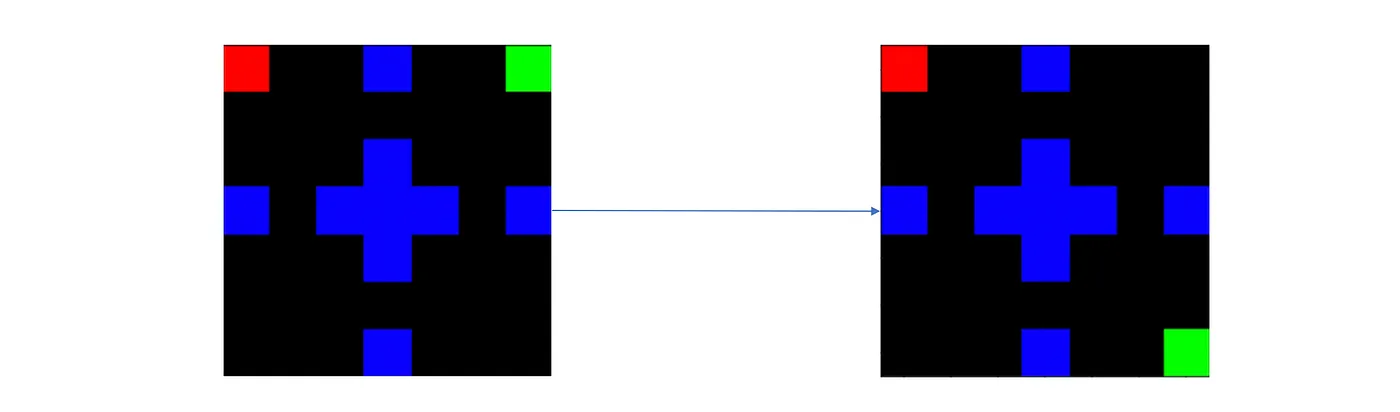

## Train the SR-learning agent

Episode 950/2000, TD Error: 0.07004582560812271, Test Lengths: 7.72
Switched reward locations
Episode 1950/2000, TD Error: 0.07522637417141574, Test Lengths: 12.18

Text(0.5, 1.0, 'Episode Lengths')

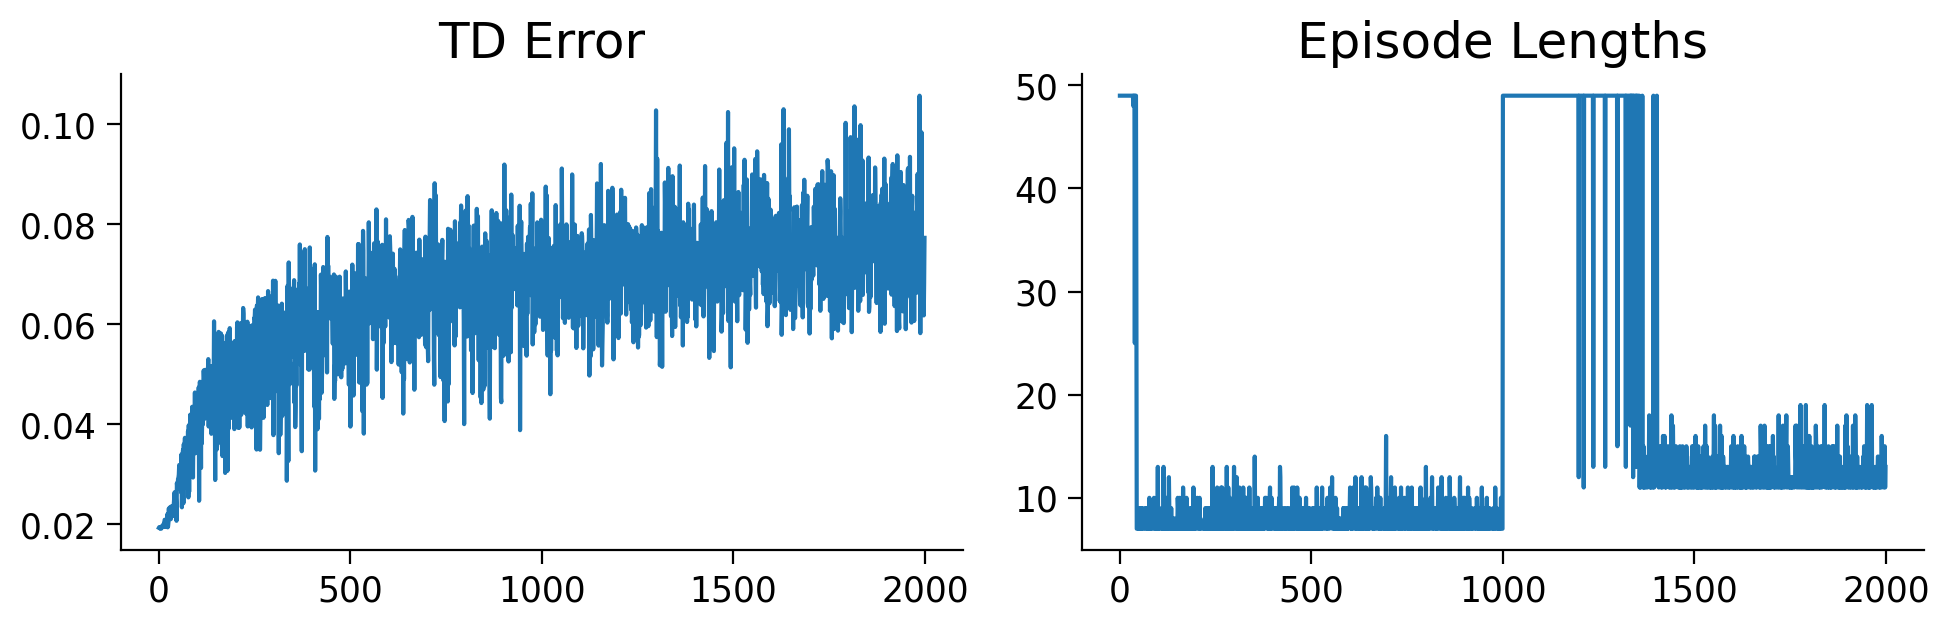

In [ ]:

train_episode_length = 50
test_episode_length = 50
episodes = 2000
gamma = 0.95
lr = 5e-2
train_epsilon = 1.0
test_epsilon = 0.1

agent = TabularSuccessorAgent(env.state_size, env.action_size, lr, gamma)

experiences = []
test_experiences = []
test_lengths = []
lifetime_td_errors = []

for i in range(episodes):
    # Train phase
    agent_start = [0,0]
    if i < episodes // 2:
        goal_pos = [0, grid_size-1]
    else:
        if i == episodes // 2:
            print("\nSwitched reward locations")
        goal_pos = [grid_size-1,grid_size-1]
    env.reset(agent_pos=agent_start, goal_pos=goal_pos)
    state = env.observation
    episodic_error = []
    for j in range(train_episode_length):
        action = agent.sample_action(state, epsilon=train_epsilon)
        reward = env.step(action)
        state_next = env.observation
        done = env.done
        experiences.append([state, action, state_next, reward, done])
        state = state_next
        if (j > 1):
            td_sr = agent.update_sr(experiences[-2], experiences[-1])
            td_w = agent.update_w(experiences[-1])
            episodic_error.append(np.mean(np.abs(td_sr)))
        if env.done:
            td_sr = agent.update_sr(experiences[-1], experiences[-1])
            episodic_error.append(np.mean(np.abs(td_sr)))
            break
    lifetime_td_errors.append(np.mean(episodic_error))

    # Test phase
    env.reset(agent_pos=agent_start, goal_pos=goal_pos)
    state = env.observation
    for j in range(test_episode_length):
        action = agent.sample_action(state, epsilon=test_epsilon)
        reward = env.step(action)
        state_next = env.observation
        test_experiences.append([state, action, state_next, reward])
        state = state_next
        if env.done:
            break
    test_lengths.append(j)

    if i % 50 == 0:
        print('\rEpisode {}/{}, TD Error: {}, Test Lengths: {}'
              .format(i, episodes, np.mean(lifetime_td_errors[-50:]),
                      np.mean(test_lengths[-50:])), end='')

fig = plt.figure(figsize=(10, 6))

ax = fig.add_subplot(2, 2, 1)
ax.plot(lifetime_td_errors)
ax.set_title("TD Error")
ax = fig.add_subplot(2, 2, 2)
ax.plot(test_lengths)
ax.set_title("Episode Lengths")


## Visualizing the successor representations

Define a function to visualize state occupancy during and after training:

In [ ]:

def print_occupancy(experiences, grid_size):
    occupancy_grid = np.zeros([grid_size, grid_size])
    for experience in experiences:
        occupancy_grid += env.state_to_grid(experience[0])
    occupancy_grid = np.sqrt(occupancy_grid)
    occupancy_grid = mask_grid(occupancy_grid, env.blocks)
    plt.imshow(occupancy_grid)



State occupancy during training:

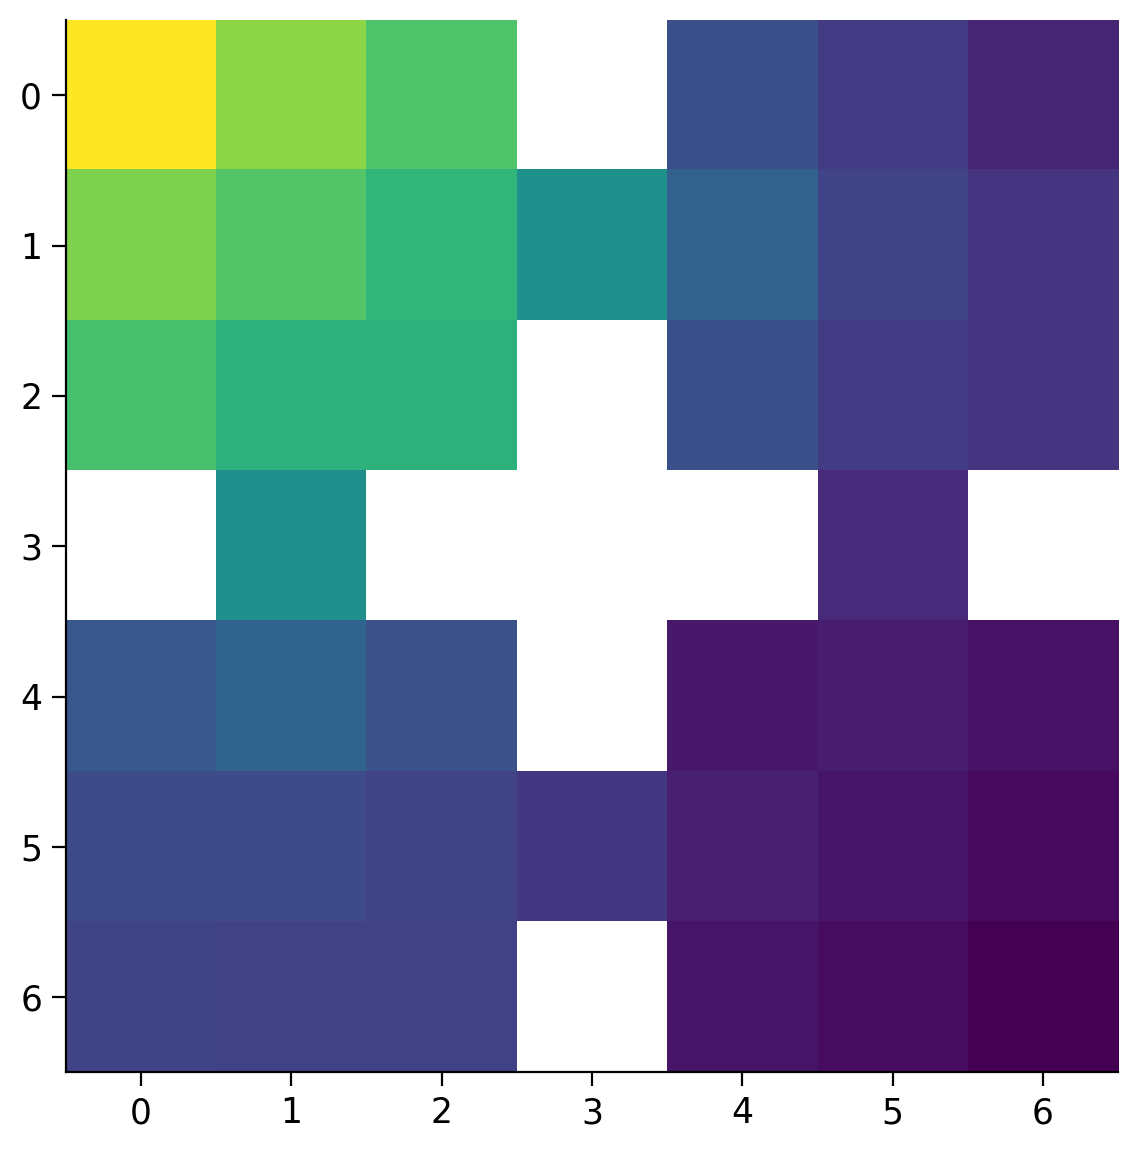

In [ ]:

print_occupancy(experiences, grid_size)

State occupancy after training:  

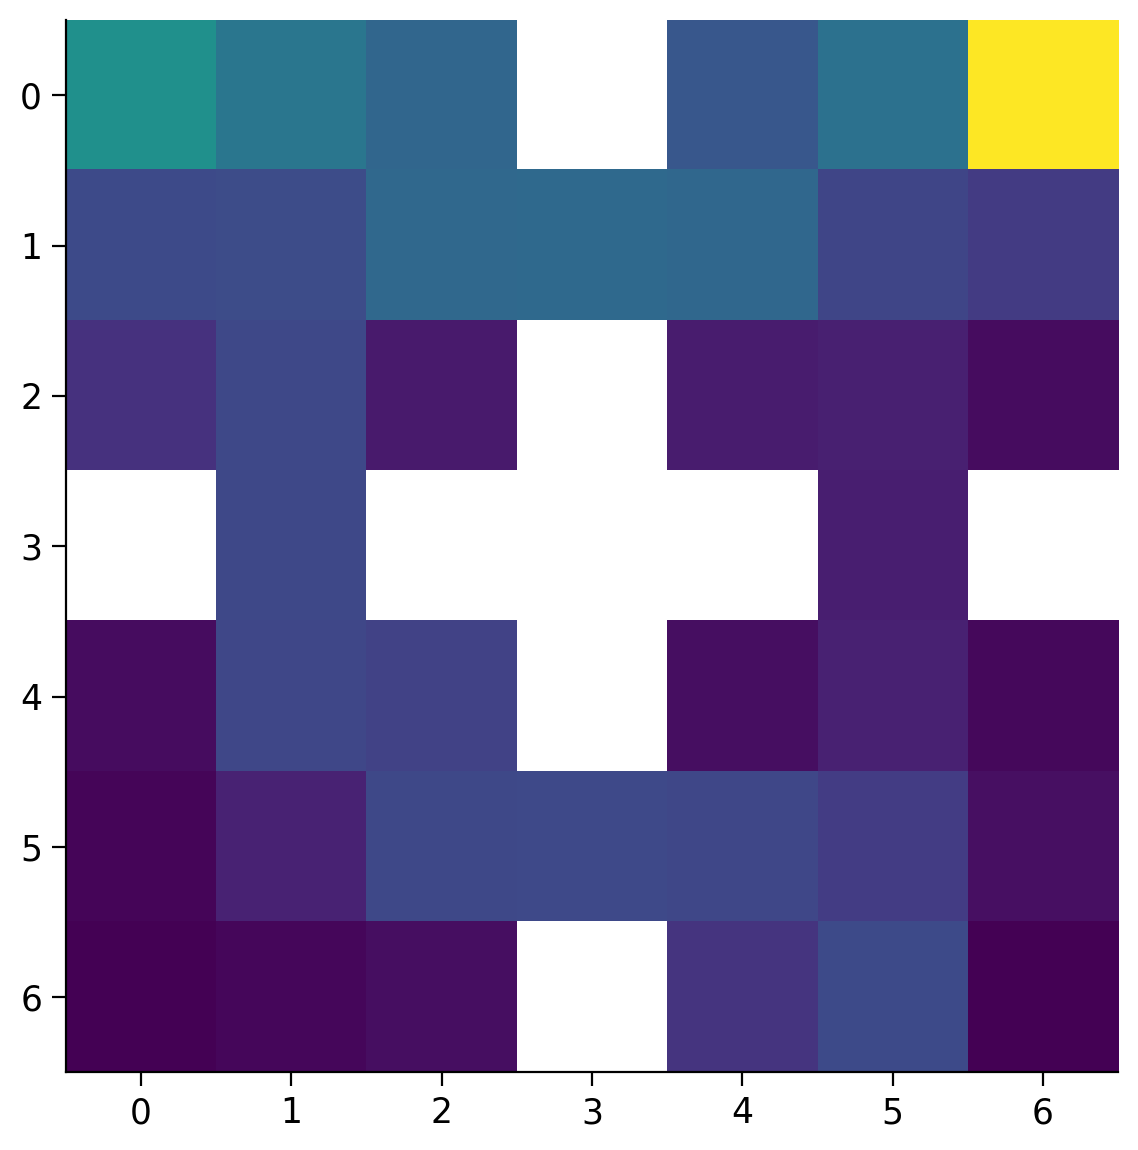

In [ ]:

print_occupancy(test_experiences, grid_size)

We can visualize SR for each state:

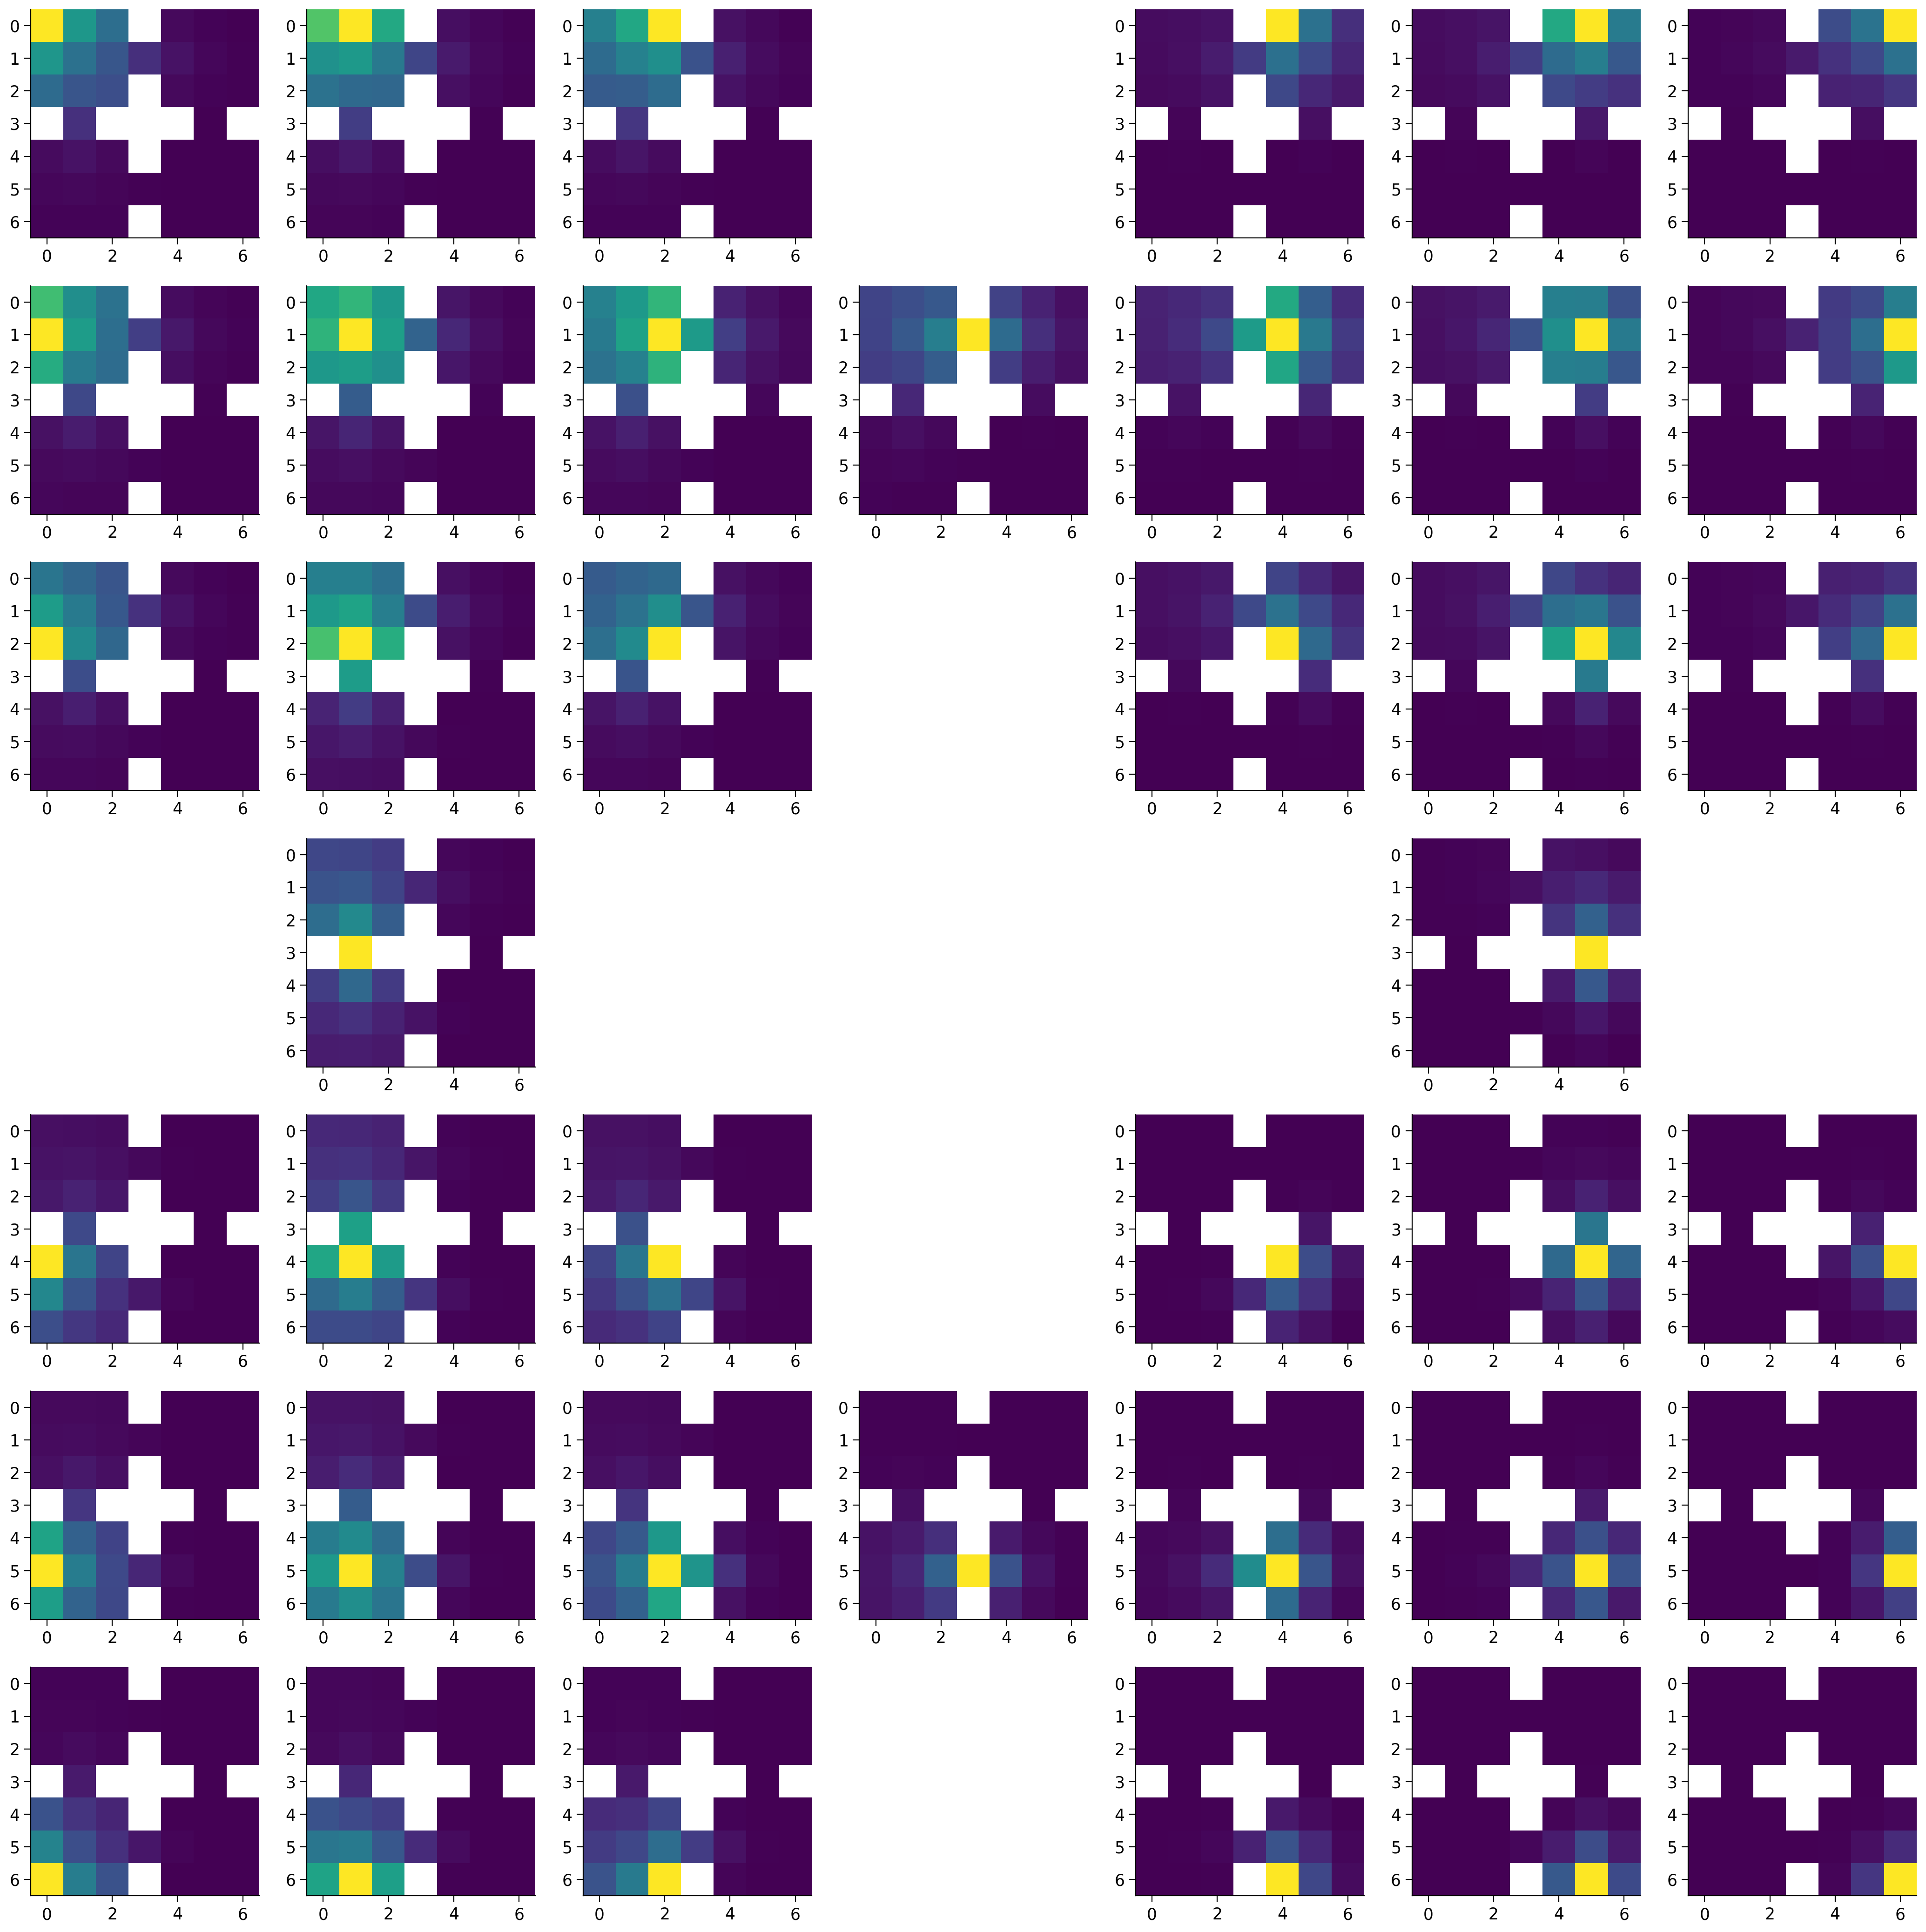

In [ ]:

averaged_M = np.mean(agent.M, axis=0)
averaged_M = np.reshape(averaged_M, [env.state_size, grid_size, grid_size])

cmap = plt.cm.viridis
cmap.set_bad(color='white')

plt.figure(1, figsize=(grid_size*3, grid_size*3))
for i in range(env.state_size):
    if env.state_to_point(i) not in env.blocks:
        ax = plt.subplot(grid_size, grid_size, i + 1)
        ax.imshow(mask_grid(averaged_M[i,:,:], env.blocks), cmap=cmap)


# Question 2

1. Can the SR-learning agent adapt to reward function changes quickly? Why?

2. Do you think the SR-learning agent can adapt to transition probability $P(s'|s,a)$ changes in the environment quickly? Why?

1. Yes, because the reward is separated from the dynamics. If the reward function changes, you don't need to relearn the successor matrix M. No need to re-experience transitions.

2. No, because the successor representation depends directly on transition dynamics. If P changes, then M is wrong. And unlike reward changes (which are linear reweightings), transition changes require relearning the predictive map itself. That takes experience.